Using device: cuda
Torch version: 2.7.1+cu118
CUDA available: True
CUDA used by PyTorch: 11.8
GPU name: NVIDIA GeForce RTX 3050 Laptop GPU
Rows with valid power data: 590
Rows with both Rs and J0 maps existing: 274
Rows removed due to missing physics maps: 316

Total valid samples: 274

Sample rows:
                                             rs_path  \
0  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
1  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
2  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
3  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
4  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   

                                             j0_path  pf_ratio  
0  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...  0.952963  
1  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...  0.948889  
2  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...  0.941111  
3  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...  0.954074  
4  c:\Users\Ghozy Abror\OneDrive - In

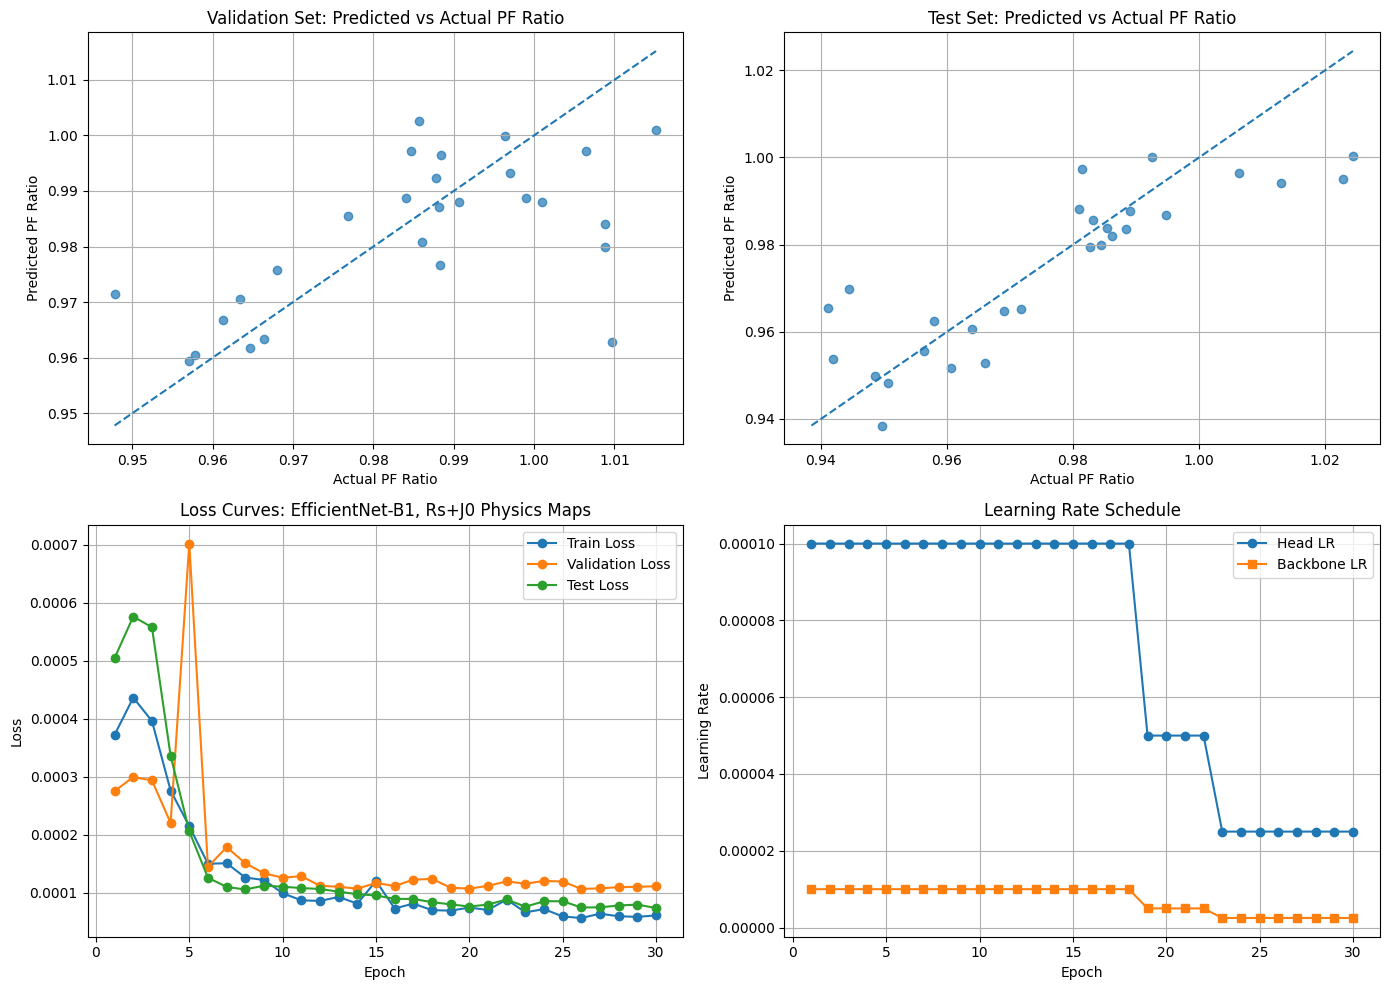


Saved:
- results_effnet_b1_physics_RsJ0.png
- validation_predictions_effnet_b1_physics_RsJ0.csv
- test_predictions_effnet_b1_physics_RsJ0.csv
- effnet_b1_physics_RsJ0_best_val_model.pth
Cleanup done.


In [1]:
import os
import math
import copy
import random
import time
import gc

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models


# =========================================================
# CONFIG
# =========================================================
CSV_PATH = "AnonDB.csv"

# EfficientNet-B1 recommended input size
IMAGE_SIZE = 240

# Physics maps are float32 and 2-channel, but EfficientNet-B1 is light.
# If CUDA out of memory, reduce to 8.
BATCH_SIZE = 16

NUM_EPOCHS = 30
LEARNING_RATE = 1e-4
BACKBONE_LR = 1e-5
RANDOM_SEED = 42
NUM_WORKERS = 0
PRELOAD_TO_RAM = True

# Folder containing the Rs and J0 maps, relative to CSV directory
PHYSICS_MAP_DIR = "J0_Rs"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", DEVICE)
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA used by PyTorch:", torch.version.cuda)

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))


# =========================================================
# REPRODUCIBILITY
# =========================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(RANDOM_SEED)


# =========================================================
# HELPER FUNCTIONS
# =========================================================
def derive_physics_paths(elh_path_str, base_dir):
    """
    Derive Rs and J0 map paths from ELHPath.

    Example:
    ELHPath: ./EL/3883_35_1_01272020_80.tiff
    Rs path: ./J0_Rs/3883_35_1_01272020_Rs.tiff
    J0 path: ./J0_Rs/3883_35_1_01272020_J0.tiff
    """
    if pd.isna(elh_path_str):
        return None, None

    elh_path_str = str(elh_path_str).strip()

    if elh_path_str == "":
        return None, None

    filename = os.path.basename(elh_path_str)
    name, ext = os.path.splitext(filename)

    # Remove last suffix, e.g. _80 or _20
    base_name = name.rsplit("_", 1)[0]

    rs_filename = f"{base_name}_Rs{ext}"
    j0_filename = f"{base_name}_J0{ext}"

    rs_path = os.path.normpath(
        os.path.join(base_dir, PHYSICS_MAP_DIR, rs_filename)
    )

    j0_path = os.path.normpath(
        os.path.join(base_dir, PHYSICS_MAP_DIR, j0_filename)
    )

    return rs_path, j0_path


def prepare_dataframe(csv_path):
    base_dir = os.path.dirname(os.path.abspath(csv_path))
    df = pd.read_csv(csv_path)

    required_cols = ["ELHPath", "Pmp_(W)", "Nameplate_Pmp_(W)"]

    for col in required_cols:
        if col not in df.columns:
            raise ValueError(f"Missing required column in CSV: {col}")

    df["Pmp_(W)"] = pd.to_numeric(df["Pmp_(W)"], errors="coerce")
    df["Nameplate_Pmp_(W)"] = pd.to_numeric(
        df["Nameplate_Pmp_(W)"],
        errors="coerce"
    )

    df = df[
        df["Nameplate_Pmp_(W)"].notna()
        & (df["Nameplate_Pmp_(W)"] > 0)
        & df["Pmp_(W)"].notna()
    ].copy()

    df["pf_ratio"] = df["Pmp_(W)"] / df["Nameplate_Pmp_(W)"]

    paths = df["ELHPath"].apply(lambda p: derive_physics_paths(p, base_dir))

    df["rs_path"] = paths.apply(lambda x: x[0])
    df["j0_path"] = paths.apply(lambda x: x[1])

    df = df[df["rs_path"].notna() & df["j0_path"].notna()].copy()

    df["rs_exists"] = df["rs_path"].apply(os.path.exists)
    df["j0_exists"] = df["j0_path"].apply(os.path.exists)

    total_before = len(df)
    df = df[df["rs_exists"] & df["j0_exists"]].copy()
    total_after = len(df)

    print(f"Rows with valid power data: {total_before}")
    print(f"Rows with both Rs and J0 maps existing: {total_after}")
    print(f"Rows removed due to missing physics maps: {total_before - total_after}")

    optional_id_cols = [
        c for c in ["ID", "ModuleID", "Module", "Serial", "PanelID"]
        if c in df.columns
    ]

    keep_cols = optional_id_cols + ["rs_path", "j0_path", "pf_ratio"]

    return df[keep_cols].reset_index(drop=True)


# =========================================================
# IMAGE / MAP PROCESSING
# =========================================================
def read_physics_map(path):
    """
    Read physics-derived Rs/J0 map as float32.

    These maps may be floating-point TIFFs, so use IMREAD_UNCHANGED.
    """
    img = cv2.imread(path, cv2.IMREAD_UNCHANGED)

    if img is None:
        raise ValueError(f"Failed to load physics map: {path}")

    if img.ndim == 3:
        img = img[:, :, 0]

    img = img.astype(np.float32)

    img = np.nan_to_num(
        img,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )

    return img


def resize_with_padding_float(img, target_size=240):
    """
    Resize floating-point map while preserving aspect ratio,
    then pad to square target_size x target_size.

    This avoids stretching the spatial pattern of Rs/J0 maps.
    """
    h, w = img.shape[:2]

    scale = target_size / max(h, w)
    new_w = int(w * scale)
    new_h = int(h * scale)

    resized = cv2.resize(
        img,
        (new_w, new_h),
        interpolation=cv2.INTER_LINEAR
    )

    canvas = np.zeros(
        (target_size, target_size),
        dtype=np.float32
    )

    y0 = (target_size - new_h) // 2
    x0 = (target_size - new_w) // 2

    canvas[y0:y0 + new_h, x0:x0 + new_w] = resized

    return canvas


def normalize_map(img):
    """
    Per-sample min-max normalization to [0, 1].

    This keeps spatial contrast inside each Rs/J0 map.
    """
    img = img.astype(np.float32)

    vmin = np.nanmin(img)
    vmax = np.nanmax(img)

    if vmax - vmin > 1e-8:
        return (img - vmin) / (vmax - vmin)

    return np.zeros_like(img, dtype=np.float32)


# =========================================================
# DATASET: 2-channel Rs + J0 physics maps
# =========================================================
class PhysicsMapDataset(Dataset):
    def __init__(self, dataframe, image_size=240, augment=False, preload=False):
        self.df = dataframe.reset_index(drop=True)
        self.image_size = image_size
        self.augment = augment
        self.cache = False

        if preload:
            self._preload_all()

    def _preload_all(self):
        """
        Read, resize, and cache all Rs/J0 maps as float32.
        """
        n = len(self.df)

        expected_mb = n * 2 * self.image_size * self.image_size * 4 / (1024 ** 2)

        print(f"\nPreloading {n} samples ({n * 2} physics maps) into RAM...")
        print(f"Expected memory: ~{expected_mb:.0f} MB")

        t0 = time.time()

        self.cache_rs = np.empty(
            (n, self.image_size, self.image_size),
            dtype=np.float32
        )

        self.cache_j0 = np.empty(
            (n, self.image_size, self.image_size),
            dtype=np.float32
        )

        failed = 0

        for i in range(n):
            row = self.df.iloc[i]

            try:
                rs_raw = read_physics_map(row["rs_path"])
                j0_raw = read_physics_map(row["j0_path"])

                self.cache_rs[i] = resize_with_padding_float(
                    rs_raw,
                    self.image_size
                )

                self.cache_j0[i] = resize_with_padding_float(
                    j0_raw,
                    self.image_size
                )

            except Exception as e:
                print(f"Warning: failed to load sample {i}: {e}")
                self.cache_rs[i] = 0.0
                self.cache_j0[i] = 0.0
                failed += 1

        elapsed = time.time() - t0

        mem_mb = (
            self.cache_rs.nbytes + self.cache_j0.nbytes
        ) / (1024 ** 2)

        print(
            f"Done in {elapsed:.1f}s | "
            f"RAM used: {mem_mb:.1f} MB | "
            f"Failed: {failed}"
        )

        self.cache = True

    def apply_same_augmentation(self, rs_img, j0_img):
        """
        Apply same augmentation to Rs and J0 pair.
        """
        if random.random() < 0.5:
            rs_img = cv2.flip(rs_img, 1)
            j0_img = cv2.flip(j0_img, 1)

        if random.random() < 0.5:
            rs_img = cv2.flip(rs_img, 0)
            j0_img = cv2.flip(j0_img, 0)

        return rs_img, j0_img

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        if self.cache:
            rs_img = self.cache_rs[idx].copy()
            j0_img = self.cache_j0[idx].copy()
        else:
            rs_img = read_physics_map(row["rs_path"])
            j0_img = read_physics_map(row["j0_path"])

            rs_img = resize_with_padding_float(rs_img, self.image_size)
            j0_img = resize_with_padding_float(j0_img, self.image_size)

        if self.augment:
            rs_img, j0_img = self.apply_same_augmentation(rs_img, j0_img)

        rs_img = normalize_map(rs_img)
        j0_img = normalize_map(j0_img)

        rs_img = np.expand_dims(rs_img, axis=0)
        j0_img = np.expand_dims(j0_img, axis=0)

        # Shape: [2, H, W]
        x = np.concatenate([rs_img, j0_img], axis=0)

        y = float(row["pf_ratio"])

        return (
            torch.tensor(x, dtype=torch.float32),
            torch.tensor(y, dtype=torch.float32)
        )


# =========================================================
# MODEL: EfficientNet-B1, 2-channel input
# =========================================================
class BoundedOutput(nn.Module):
    def __init__(self, in_features, min_val=0.80, max_val=1.20):
        super().__init__()
        self.linear = nn.Linear(in_features, 1)
        self.min_val = min_val
        self.max_val = max_val

    def forward(self, x):
        x = torch.sigmoid(self.linear(x))
        return x * (self.max_val - self.min_val) + self.min_val


def build_efficientnet_b1_2ch(pretrained=True):
    """
    EfficientNet-B1 modified to accept 2-channel input:
    channel 0 = Rs map
    channel 1 = J0 map

    Output: one bounded PF ratio prediction.
    """
    weights = models.EfficientNet_B1_Weights.DEFAULT if pretrained else None
    model = models.efficientnet_b1(weights=weights)

    old_conv = model.features[0][0]

    new_conv = nn.Conv2d(
        in_channels=2,
        out_channels=old_conv.out_channels,
        kernel_size=old_conv.kernel_size,
        stride=old_conv.stride,
        padding=old_conv.padding,
        bias=False
    )

    with torch.no_grad():
        if pretrained:
            # Convert RGB pretrained filters into grayscale-like filters,
            # then use the same initialization for Rs and J0 channels.
            rgb_mean = old_conv.weight.mean(dim=1)

            new_conv.weight[:, 0, :, :] = rgb_mean
            new_conv.weight[:, 1, :, :] = rgb_mean

            # Keep activation magnitude more stable for 2-channel input.
            new_conv.weight *= 0.5

        else:
            nn.init.kaiming_normal_(
                new_conv.weight,
                mode="fan_out",
                nonlinearity="relu"
            )

    model.features[0][0] = new_conv

    in_features = model.classifier[1].in_features

    model.classifier[1] = BoundedOutput(
        in_features,
        min_val=0.80,
        max_val=1.20
    )

    return model


# =========================================================
# TRAIN / EVALUATE
# =========================================================
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0

    for inputs, targets in loader:
        inputs = inputs.to(device)
        targets = targets.to(device).unsqueeze(1)

        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, targets)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

    return running_loss / len(loader.dataset)


def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    preds = []
    trues = []

    with torch.no_grad():
        for inputs, targets in loader:
            inputs = inputs.to(device)
            targets = targets.to(device).unsqueeze(1)

            outputs = model(inputs)
            loss = criterion(outputs, targets)

            running_loss += loss.item() * inputs.size(0)

            preds.extend(outputs.squeeze(1).cpu().numpy())
            trues.extend(targets.squeeze(1).cpu().numpy())

    preds = np.array(preds)
    trues = np.array(trues)

    loss_value = running_loss / len(loader.dataset)
    mae = mean_absolute_error(trues, preds)
    rmse = math.sqrt(mean_squared_error(trues, preds))
    r2 = r2_score(trues, preds)

    return loss_value, mae, rmse, r2, preds, trues


# =========================================================
# PLOTTING
# =========================================================
def plot_scatter(ax, trues, preds, title):
    ax.scatter(trues, preds, alpha=0.7)

    min_val = min(trues.min(), preds.min())
    max_val = max(trues.max(), preds.max())

    ax.plot([min_val, max_val], [min_val, max_val], linestyle="--")

    ax.set_xlabel("Actual PF Ratio")
    ax.set_ylabel("Predicted PF Ratio")
    ax.set_title(title)
    ax.grid(True)


# =========================================================
# MAIN
# =========================================================
def main():
    df = prepare_dataframe(CSV_PATH)

    if len(df) < 20:
        raise ValueError("Too few valid samples remain after filtering.")

    print(f"\nTotal valid samples: {len(df)}")
    print("\nSample rows:")
    print(df.head())

    train_df, temp_df = train_test_split(
        df,
        test_size=0.2,
        random_state=RANDOM_SEED
    )

    val_df, test_df = train_test_split(
        temp_df,
        test_size=0.5,
        random_state=RANDOM_SEED
    )

    print(f"\nTrain samples: {len(train_df)}")
    print(f"Val samples:   {len(val_df)}")
    print(f"Test samples:  {len(test_df)}")

    train_dataset = PhysicsMapDataset(
        train_df,
        image_size=IMAGE_SIZE,
        augment=True,
        preload=PRELOAD_TO_RAM
    )

    val_dataset = PhysicsMapDataset(
        val_df,
        image_size=IMAGE_SIZE,
        augment=False,
        preload=PRELOAD_TO_RAM
    )

    test_dataset = PhysicsMapDataset(
        test_df,
        image_size=IMAGE_SIZE,
        augment=False,
        preload=PRELOAD_TO_RAM
    )

    pin_memory = True if DEVICE.type == "cuda" else False

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=pin_memory
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=pin_memory
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=pin_memory
    )

    # -------------------------
    # Model
    # -------------------------
    model = build_efficientnet_b1_2ch(pretrained=True).to(DEVICE)

    print("Model is on:", next(model.parameters()).device)

    backbone_params = list(model.features.parameters())
    head_params = list(model.classifier.parameters())

    print(f"\nBackbone parameters: {sum(p.numel() for p in backbone_params):,}")
    print(f"Head parameters:     {sum(p.numel() for p in head_params):,}")
    print(f"Total parameters:    {sum(p.numel() for p in model.parameters()):,}")
    print(f"Backbone LR: {BACKBONE_LR:.1e} | Head LR: {LEARNING_RATE:.1e}")

    criterion = nn.SmoothL1Loss()

    optimizer = torch.optim.AdamW(
        [
            {"params": backbone_params, "lr": BACKBONE_LR},
            {"params": head_params, "lr": LEARNING_RATE},
        ],
        weight_decay=1e-2
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=3
    )

    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_rmse = float("inf")

    train_losses = []
    val_losses = []
    test_losses = []

    head_lrs = []
    backbone_lrs = []

    print(f"\n{'=' * 70}")
    print("Starting training: EfficientNet-B1, 2ch Rs+J0 physics maps")
    print(f"Image size: {IMAGE_SIZE}x{IMAGE_SIZE} | Batch size: {BATCH_SIZE}")
    print(f"{'=' * 70}\n")

    total_t0 = time.time()

    for epoch in range(NUM_EPOCHS):
        epoch_t0 = time.time()

        current_backbone_lr = optimizer.param_groups[0]["lr"]
        current_head_lr = optimizer.param_groups[1]["lr"]

        backbone_lrs.append(current_backbone_lr)
        head_lrs.append(current_head_lr)

        train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            DEVICE
        )

        train_eval_loss, train_mae, train_rmse, train_r2, _, _ = evaluate(
            model,
            train_loader,
            criterion,
            DEVICE
        )

        val_loss, val_mae, val_rmse, val_r2, _, _ = evaluate(
            model,
            val_loader,
            criterion,
            DEVICE
        )

        test_loss, test_mae, test_rmse, test_r2, _, _ = evaluate(
            model,
            test_loader,
            criterion,
            DEVICE
        )

        scheduler.step(val_loss)

        train_losses.append(train_eval_loss)
        val_losses.append(val_loss)
        test_losses.append(test_loss)

        epoch_time = time.time() - epoch_t0

        print(
            f"Epoch [{epoch + 1:02d}/{NUM_EPOCHS}] | "
            f"{epoch_time:.1f}s | "
            f"BB_LR: {current_backbone_lr:.2e} | "
            f"Head_LR: {current_head_lr:.2e} | "
            f"Train Loss: {train_eval_loss:.6f} | "
            f"Val Loss: {val_loss:.6f} | "
            f"Test Loss: {test_loss:.6f} | "
            f"Val MAE: {val_mae:.6f} | "
            f"Val RMSE: {val_rmse:.6f} | "
            f"Val R2: {val_r2:.6f}"
        )

        if val_rmse < best_val_rmse:
            best_val_rmse = val_rmse
            best_model_wts = copy.deepcopy(model.state_dict())

    total_time = time.time() - total_t0

    print(f"\nTraining complete in {total_time:.1f}s ({total_time / 60:.1f} min)")

    # -------------------------
    # Final evaluation
    # -------------------------
    model.load_state_dict(best_model_wts)

    val_loss, val_mae, val_rmse, val_r2, val_preds, val_trues = evaluate(
        model,
        val_loader,
        criterion,
        DEVICE
    )

    test_loss, test_mae, test_rmse, test_r2, test_preds, test_trues = evaluate(
        model,
        test_loader,
        criterion,
        DEVICE
    )

    print("\nBest Model Performance selected by Validation RMSE")

    print("\nValidation Set")
    print(f"MAE  : {val_mae:.6f}")
    print(f"RMSE : {val_rmse:.6f}")
    print(f"R2   : {val_r2:.6f}")

    print("\nTest Set")
    print(f"MAE  : {test_mae:.6f}")
    print(f"RMSE : {test_rmse:.6f}")
    print(f"R2   : {test_r2:.6f}")

    # -------------------------
    # Plotting
    # -------------------------
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    plot_scatter(
        axes[0, 0],
        val_trues,
        val_preds,
        "Validation Set: Predicted vs Actual PF Ratio"
    )

    plot_scatter(
        axes[0, 1],
        test_trues,
        test_preds,
        "Test Set: Predicted vs Actual PF Ratio"
    )

    axes[1, 0].plot(
        range(1, NUM_EPOCHS + 1),
        train_losses,
        label="Train Loss",
        marker="o"
    )

    axes[1, 0].plot(
        range(1, NUM_EPOCHS + 1),
        val_losses,
        label="Validation Loss",
        marker="o"
    )

    axes[1, 0].plot(
        range(1, NUM_EPOCHS + 1),
        test_losses,
        label="Test Loss",
        marker="o"
    )

    axes[1, 0].set_xlabel("Epoch")
    axes[1, 0].set_ylabel("Loss")
    axes[1, 0].set_title("Loss Curves: EfficientNet-B1, Rs+J0 Physics Maps")
    axes[1, 0].legend()
    axes[1, 0].grid(True)

    axes[1, 1].plot(
        range(1, NUM_EPOCHS + 1),
        head_lrs,
        marker="o",
        label="Head LR"
    )

    axes[1, 1].plot(
        range(1, NUM_EPOCHS + 1),
        backbone_lrs,
        marker="s",
        label="Backbone LR"
    )

    axes[1, 1].set_xlabel("Epoch")
    axes[1, 1].set_ylabel("Learning Rate")
    axes[1, 1].set_title("Learning Rate Schedule")
    axes[1, 1].legend()
    axes[1, 1].grid(True)

    plt.tight_layout()

    fig_path = "results_effnet_b1_physics_RsJ0.png"

    plt.savefig(
        fig_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    # -------------------------
    # Save prediction tables
    # -------------------------
    val_results_df = pd.DataFrame(
        {
            "actual_pf_ratio": val_trues,
            "predicted_pf_ratio": val_preds
        }
    )

    val_csv_path = "validation_predictions_effnet_b1_physics_RsJ0.csv"
    val_results_df.to_csv(val_csv_path, index=False)

    test_results_df = pd.DataFrame(
        {
            "actual_pf_ratio": test_trues,
            "predicted_pf_ratio": test_preds
        }
    )

    test_csv_path = "test_predictions_effnet_b1_physics_RsJ0.csv"
    test_results_df.to_csv(test_csv_path, index=False)

    save_path = "effnet_b1_physics_RsJ0_best_val_model.pth"
    torch.save(model.state_dict(), save_path)

    print("\nSaved:")
    print(f"- {fig_path}")
    print(f"- {val_csv_path}")
    print(f"- {test_csv_path}")
    print(f"- {save_path}")


if __name__ == "__main__":
    try:
        main()

    except KeyboardInterrupt:
        print("\nTraining stopped manually by user.")

    finally:
        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            torch.cuda.ipc_collect()

        print("Cleanup done.")

Using device: cuda
Torch version: 2.7.1+cu118
CUDA available: True
CUDA used by PyTorch: 11.8
GPU name: NVIDIA GeForce RTX 3050 Laptop GPU
Rows with valid power data before file filtering: 590
Rows with high-bias EL image existing: 584
Rows removed due to missing high-bias image: 6

Sample rows:
   Make make_plot  split                                          high_path  \
0    35        35    val  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
1    35        35  train  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
2    35        35  train  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
3    35        35    val  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
4    35        35  train  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   

   pf_ratio  
0  0.952963  
1  0.948889  
2  0.941111  
3  0.954074  
4  0.944074  

Split counts after file filtering:
split
train    463
val       61
test      60
Name: count, dtype: int64

Make by split after file filtering:


Using device: cuda
Torch version: 2.7.1+cu118
CUDA available: True
CUDA used by PyTorch: 11.8
GPU name: NVIDIA GeForce RTX 3050 Laptop GPU
Rows with valid power data before map filtering: 590
Rows with both Rs and Io/J0 maps existing: 274
Rows removed due to missing physics map(s): 316

Sample rows:
   Make make_plot  split                                            rs_path  \
0    35        35    val  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
1    35        35  train  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
2    35        35  train  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
3    35        35    val  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
4    35        35  train  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   

                                             io_path  pf_ratio  
0  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...  0.952963  
1  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...  0.948889  
2  c:\Users\Ghozy Abror\OneDr

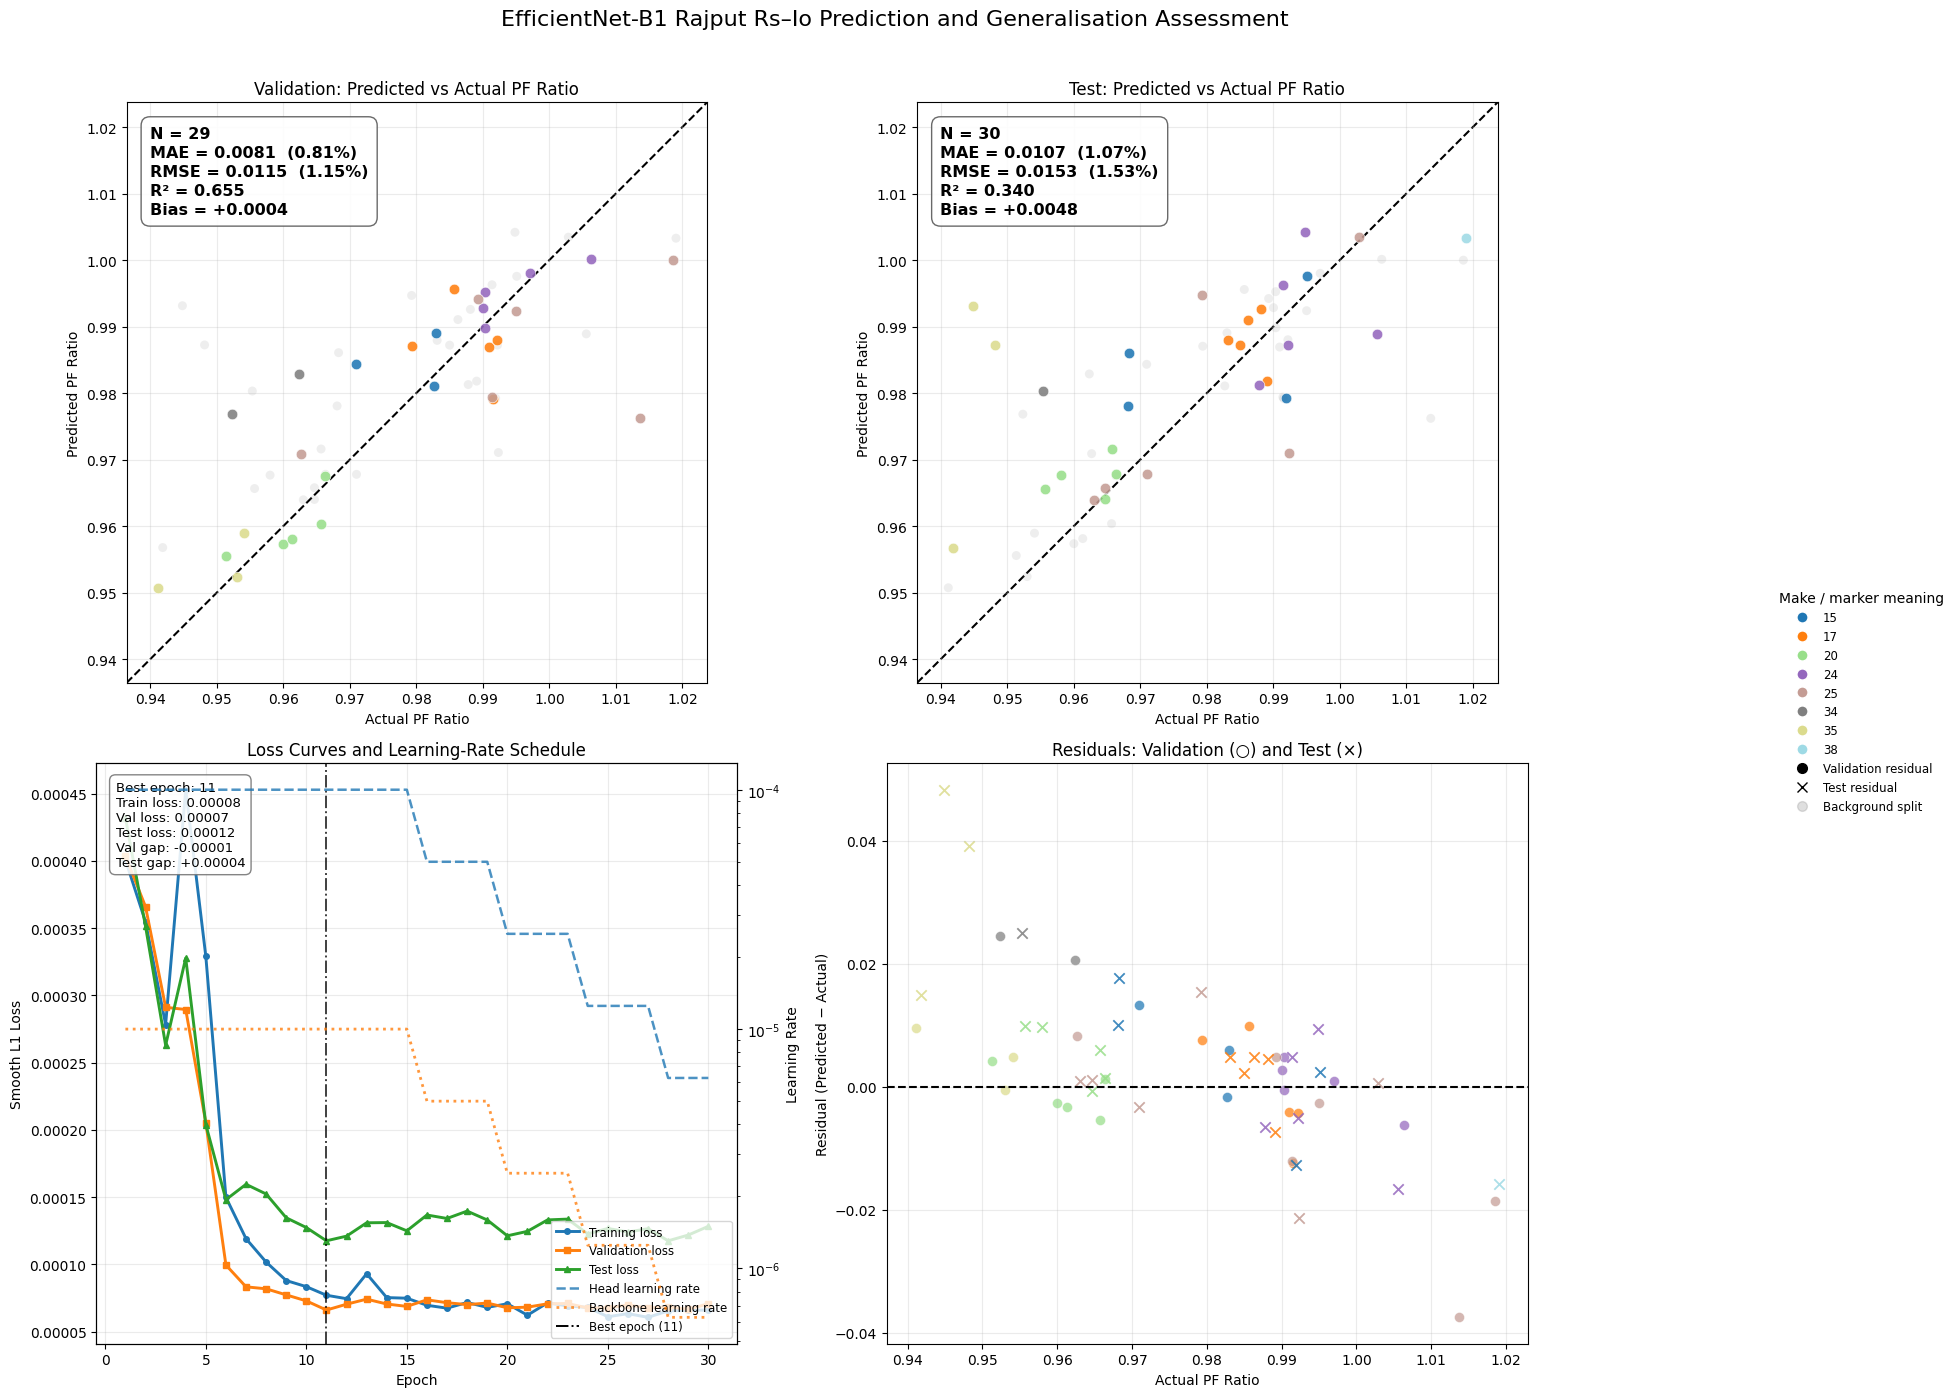


Saved:
- results_effnet_b1_rajput_rs_io_fixedsplit_generalization.png
- validation_predictions_effnet_b1_rajput_rs_io_fixedsplit.csv
- test_predictions_effnet_b1_rajput_rs_io_fixedsplit.csv
- metrics_per_make_effnet_b1_rajput_rs_io_fixedsplit.csv
- training_history_effnet_b1_rajput_rs_io_fixedsplit.csv
- effnet_b1_rajput_rs_io_fixedsplit_best_val_model.pth
Cleanup done.


In [2]:
import os
import math
import copy
import random
import time
import gc

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models


# =========================================================
# CONFIG
# =========================================================
CSV_PATH = "AnonDB_80_10_10_seed42.csv"
MAKE_COLUMN = "Make"
SPLIT_COLUMN = "split"
PHYSICS_MAP_DIR = "J0_Rs"  # folder containing Rs and Io/J0 TIFF maps

IMAGE_SIZE = 240
BATCH_SIZE = 16  # reduce to 8 if CUDA runs out of memory
NUM_EPOCHS = 30
LEARNING_RATE = 1e-4
BACKBONE_LR = 1e-5
RANDOM_SEED = 42
NUM_WORKERS = 0
PRELOAD_TO_RAM = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", DEVICE)
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA used by PyTorch:", torch.version.cuda)

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))


# =========================================================
# REPRODUCIBILITY
# =========================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    if torch.cuda.is_available():
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


set_seed(RANDOM_SEED)


# =========================================================
# HELPER FUNCTIONS
# =========================================================
def resolve_relative_path(path_str, base_dir, add_wrp=True):
    """Resolve paths from the CSV relative to the CSV directory."""
    if pd.isna(path_str):
        return None

    path_str = str(path_str).strip()
    if path_str == "":
        return None

    path_str = path_str.replace("\\", os.sep).replace("/", os.sep)

    if add_wrp:
        root, ext = os.path.splitext(path_str)
        if not root.endswith("_wrp"):
            path_str = root + "_wrp" + ext

    if os.path.isabs(path_str):
        return os.path.normpath(path_str)

    if path_str.startswith("." + os.sep):
        path_str = path_str[2:]

    return os.path.normpath(os.path.join(base_dir, path_str))


def derive_physics_paths(elh_path_str, base_dir):
    """
    Derive Rajput Rs and Io map paths from ELHPath.

    Example:
        ELHPath: ./EL/3883_35_1_01272020_80.tiff
        Rs:      ./J0_Rs/3883_35_1_01272020_Rs.tiff
        Io:      ./J0_Rs/3883_35_1_01272020_Io.tiff

    For compatibility, the Io map also falls back to _J0.tiff when _Io.tiff
    does not exist.
    """
    if pd.isna(elh_path_str):
        return None, None

    elh_path_str = str(elh_path_str).strip()
    if elh_path_str == "":
        return None, None

    filename = os.path.basename(elh_path_str)
    name, ext = os.path.splitext(filename)
    base_name = name.rsplit("_", 1)[0]

    rs_path = os.path.normpath(
        os.path.join(base_dir, PHYSICS_MAP_DIR, f"{base_name}_Rs{ext}")
    )

    io_path = os.path.normpath(
        os.path.join(base_dir, PHYSICS_MAP_DIR, f"{base_name}_Io{ext}")
    )
    j0_fallback = os.path.normpath(
        os.path.join(base_dir, PHYSICS_MAP_DIR, f"{base_name}_J0{ext}")
    )

    if not os.path.exists(io_path) and os.path.exists(j0_fallback):
        io_path = j0_fallback

    return rs_path, io_path


def prepare_dataframe(csv_path):
    """
    Load the fixed-split CSV, compute PF ratio, derive Rajput Rs/Io paths,
    and retain Make and split information for plotting.
    """
    base_dir = os.path.dirname(os.path.abspath(csv_path))
    df = pd.read_csv(csv_path)

    required_cols = [
        "ELHPath",
        "Pmp_(W)",
        "Nameplate_Pmp_(W)",
        MAKE_COLUMN,
        SPLIT_COLUMN,
    ]

    for col in required_cols:
        if col not in df.columns:
            raise ValueError(f"Missing required column in CSV: {col}")

    df["Pmp_(W)"] = pd.to_numeric(df["Pmp_(W)"], errors="coerce")
    df["Nameplate_Pmp_(W)"] = pd.to_numeric(
        df["Nameplate_Pmp_(W)"], errors="coerce"
    )

    df = df[
        df["Nameplate_Pmp_(W)"].notna()
        & (df["Nameplate_Pmp_(W)"] > 0)
        & df["Pmp_(W)"].notna()
    ].copy()

    df["pf_ratio"] = df["Pmp_(W)"] / df["Nameplate_Pmp_(W)"]

    paths = df["ELHPath"].apply(lambda p: derive_physics_paths(p, base_dir))
    df["rs_path"] = paths.apply(lambda item: item[0])
    df["io_path"] = paths.apply(lambda item: item[1])

    df = df[df["rs_path"].notna() & df["io_path"].notna()].copy()
    df["rs_exists"] = df["rs_path"].apply(os.path.exists)
    df["io_exists"] = df["io_path"].apply(os.path.exists)

    total_before = len(df)
    df = df[df["rs_exists"] & df["io_exists"]].copy()
    total_after = len(df)

    print(f"Rows with valid power data before map filtering: {total_before}")
    print(f"Rows with both Rs and Io/J0 maps existing: {total_after}")
    print(f"Rows removed due to missing physics map(s): {total_before - total_after}")

    df[SPLIT_COLUMN] = df[SPLIT_COLUMN].astype(str).str.strip().str.lower()
    valid_split_names = {"train", "val", "test"}
    unknown_splits = set(df[SPLIT_COLUMN].unique()) - valid_split_names
    if unknown_splits:
        raise ValueError(
            "Unknown values in split column: " + ", ".join(sorted(unknown_splits))
        )

    df["make_plot"] = df[MAKE_COLUMN].fillna("Unknown").astype(str)

    optional_id_cols = [
        c
        for c in ["ID", "ModuleID", "Module", "Serial", "PanelID"]
        if c in df.columns
    ]

    keep_cols = optional_id_cols + [
        MAKE_COLUMN,
        "make_plot",
        SPLIT_COLUMN,
        "rs_path",
        "io_path",
        "pf_ratio",
    ]
    return df[keep_cols].reset_index(drop=True)


# =========================================================
# IMAGE PROCESSING
# =========================================================
def read_physics_map(path):
    """Read a floating-point Rajput physics map without forcing it to uint8."""
    img = cv2.imread(path, cv2.IMREAD_UNCHANGED)
    if img is None:
        raise ValueError(f"Failed to load physics map: {path}")

    if img.ndim == 3:
        img = img[:, :, 0]

    img = img.astype(np.float32)
    return np.nan_to_num(img, nan=0.0, posinf=0.0, neginf=0.0)


def resize_with_padding_float(img, target_size=240):
    """Preserve map aspect ratio and pad to a float32 square input."""
    h, w = img.shape[:2]
    scale = target_size / max(h, w)
    new_w = max(1, int(round(w * scale)))
    new_h = max(1, int(round(h * scale)))

    interpolation = cv2.INTER_AREA if scale < 1 else cv2.INTER_LINEAR
    resized = cv2.resize(img, (new_w, new_h), interpolation=interpolation)

    canvas = np.zeros((target_size, target_size), dtype=np.float32)
    y0 = (target_size - new_h) // 2
    x0 = (target_size - new_w) // 2
    canvas[y0:y0 + new_h, x0:x0 + new_w] = resized
    return canvas


def robust_normalize_map(img, lower_percentile=1.0, upper_percentile=99.0):
    """
    Robust per-map normalization to [0, 1]. This preserves spatial patterns
    while reducing the influence of extreme Rs/Io pixels.
    """
    finite = img[np.isfinite(img)]
    if finite.size == 0:
        return np.zeros_like(img, dtype=np.float32)

    low = np.percentile(finite, lower_percentile)
    high = np.percentile(finite, upper_percentile)
    if high - low <= 1e-12:
        return np.zeros_like(img, dtype=np.float32)

    clipped = np.clip(img, low, high)
    return ((clipped - low) / (high - low)).astype(np.float32)


# =========================================================
# DATASET
# =========================================================
class RajputPhysicsDataset(Dataset):
    def __init__(self, dataframe, image_size=240, augment=False, preload=False):
        self.df = dataframe.reset_index(drop=True)
        self.image_size = image_size
        self.augment = augment
        self.cache = False

        if preload:
            self._preload_all()

    def _preload_all(self):
        n = len(self.df)
        expected_mb = n * 2 * self.image_size * self.image_size * 4 / (1024 ** 2)

        print(f"\nPreloading {n} samples ({n * 2} Rajput maps) into RAM...")
        print(f"Expected memory: ~{expected_mb:.0f} MB")

        t0 = time.time()
        self.cache_rs = np.empty(
            (n, self.image_size, self.image_size), dtype=np.float32
        )
        self.cache_io = np.empty(
            (n, self.image_size, self.image_size), dtype=np.float32
        )

        failed = 0
        for i in range(n):
            row = self.df.iloc[i]
            try:
                rs_img = read_physics_map(row["rs_path"])
                io_img = read_physics_map(row["io_path"])

                self.cache_rs[i] = resize_with_padding_float(
                    rs_img, self.image_size
                )
                self.cache_io[i] = resize_with_padding_float(
                    io_img, self.image_size
                )
            except Exception as e:
                print(f"Warning: failed to load sample {i}: {e}")
                self.cache_rs[i] = 0.0
                self.cache_io[i] = 0.0
                failed += 1

        elapsed = time.time() - t0
        mem_mb = (self.cache_rs.nbytes + self.cache_io.nbytes) / (1024 ** 2)
        print(
            f"Done in {elapsed:.1f}s | "
            f"RAM used: {mem_mb:.1f} MB | "
            f"Failed: {failed}"
        )
        self.cache = True

    def apply_same_augmentation(self, rs_img, io_img):
        if random.random() < 0.5:
            rs_img = cv2.flip(rs_img, 1)
            io_img = cv2.flip(io_img, 1)
        if random.random() < 0.5:
            rs_img = cv2.flip(rs_img, 0)
            io_img = cv2.flip(io_img, 0)
        return rs_img, io_img

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        if self.cache:
            rs_img = self.cache_rs[idx].copy()
            io_img = self.cache_io[idx].copy()
        else:
            rs_img = resize_with_padding_float(
                read_physics_map(row["rs_path"]), self.image_size
            )
            io_img = resize_with_padding_float(
                read_physics_map(row["io_path"]), self.image_size
            )

        if self.augment:
            rs_img, io_img = self.apply_same_augmentation(rs_img, io_img)

        rs_img = robust_normalize_map(rs_img)
        io_img = robust_normalize_map(io_img)

        rs_img = np.expand_dims(rs_img, axis=0)
        io_img = np.expand_dims(io_img, axis=0)

        # Channel 0 = Rajput Rs map; channel 1 = Rajput Io/J0 map
        x = np.concatenate([rs_img, io_img], axis=0)
        y = float(row["pf_ratio"])

        return (
            torch.tensor(x, dtype=torch.float32),
            torch.tensor(y, dtype=torch.float32),
        )


# =========================================================
# MODEL
# =========================================================
class BoundedOutput(nn.Module):
    def __init__(self, in_features, min_val=0.80, max_val=1.20):
        super().__init__()
        self.linear = nn.Linear(in_features, 1)
        self.min_val = min_val
        self.max_val = max_val

    def forward(self, x):
        x = torch.sigmoid(self.linear(x))
        return x * (self.max_val - self.min_val) + self.min_val


def build_efficientnet_b1_2ch(pretrained=True):
    """EfficientNet-B1 modified for two Rajput physics-map channels: Rs and Io/J0."""
    weights = models.EfficientNet_B1_Weights.DEFAULT if pretrained else None
    model = models.efficientnet_b1(weights=weights)

    old_conv = model.features[0][0]

    new_conv = nn.Conv2d(
        in_channels=2,
        out_channels=old_conv.out_channels,
        kernel_size=old_conv.kernel_size,
        stride=old_conv.stride,
        padding=old_conv.padding,
        bias=False,
    )

    with torch.no_grad():
        if pretrained:
            rgb_mean = old_conv.weight.mean(dim=1)
            new_conv.weight[:, 0, :, :] = rgb_mean
            new_conv.weight[:, 1, :, :] = rgb_mean
            new_conv.weight *= 0.5
        else:
            nn.init.kaiming_normal_(
                new_conv.weight, mode="fan_out", nonlinearity="relu"
            )

    model.features[0][0] = new_conv

    in_features = model.classifier[1].in_features
    model.classifier[1] = BoundedOutput(
        in_features, min_val=0.80, max_val=1.20
    )

    return model


# =========================================================
# TRAIN / EVALUATE
# =========================================================
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0

    for inputs, targets in loader:
        inputs = inputs.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True).unsqueeze(1)

        optimizer.zero_grad(set_to_none=True)

        outputs = model(inputs)
        loss = criterion(outputs, targets)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

    return running_loss / len(loader.dataset)


def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    preds = []
    trues = []

    with torch.no_grad():
        for inputs, targets in loader:
            inputs = inputs.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True).unsqueeze(1)

            outputs = model(inputs)
            loss = criterion(outputs, targets)

            running_loss += loss.item() * inputs.size(0)

            preds.extend(outputs.squeeze(1).cpu().numpy())
            trues.extend(targets.squeeze(1).cpu().numpy())

    preds = np.asarray(preds)
    trues = np.asarray(trues)

    loss_value = running_loss / len(loader.dataset)
    mae = mean_absolute_error(trues, preds)
    rmse = math.sqrt(mean_squared_error(trues, preds))
    r2 = r2_score(trues, preds) if len(trues) >= 2 else np.nan

    return loss_value, mae, rmse, r2, preds, trues


# =========================================================
# PLOTTING HELPERS
# =========================================================
def build_make_palette(make_values):
    """Create a stable qualitative colour palette for all Make values."""
    makes = sorted(pd.Series(make_values).fillna("Unknown").astype(str).unique())

    # tab20 is clear and publication-friendly for up to roughly 20 categories.
    base_cmap = plt.colormaps.get_cmap("tab20")
    colours = [base_cmap(i / max(1, len(makes) - 1)) for i in range(len(makes))]

    return dict(zip(makes, colours))


def common_scatter_limits(*dataframes):
    values = []

    for df in dataframes:
        values.extend(df["actual_pf_ratio"].to_numpy())
        values.extend(df["predicted_pf_ratio"].to_numpy())

    minimum = float(np.min(values))
    maximum = float(np.max(values))
    margin = max((maximum - minimum) * 0.06, 0.003)

    return minimum - margin, maximum + margin


def plot_focus_scatter_with_background(
    ax,
    focus_df,
    background_df,
    make_palette,
    title,
    background_label,
    axis_limits,
):
    """Highlight one split by Make and show the other split in faint grey."""
    ax.scatter(
        background_df["actual_pf_ratio"],
        background_df["predicted_pf_ratio"],
        s=42,
        color="grey",
        alpha=0.13,
        edgecolors="none",
        label=background_label,
        zorder=1,
    )

    for make_value, group in focus_df.groupby("make_plot", sort=True):
        ax.scatter(
            group["actual_pf_ratio"],
            group["predicted_pf_ratio"],
            s=58,
            color=make_palette[make_value],
            alpha=0.88,
            edgecolors="white",
            linewidths=0.5,
            label=make_value,
            zorder=2,
        )

    minimum, maximum = axis_limits

    ax.plot(
        [minimum, maximum],
        [minimum, maximum],
        linestyle="--",
        linewidth=1.5,
        color="black",
        label="Ideal prediction",
        zorder=0,
    )

    ax.set_xlim(minimum, maximum)
    ax.set_ylim(minimum, maximum)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("Actual PF Ratio")
    ax.set_ylabel("Predicted PF Ratio")
    ax.set_title(title)
    ax.grid(True, alpha=0.25)

    # Large, direct performance annotation for the highlighted split.
    actual = focus_df["actual_pf_ratio"].to_numpy()
    predicted = focus_df["predicted_pf_ratio"].to_numpy()
    residual = predicted - actual

    mae = mean_absolute_error(actual, predicted)
    rmse = math.sqrt(mean_squared_error(actual, predicted))
    r2 = r2_score(actual, predicted) if len(actual) >= 2 else float("nan")
    bias = float(np.mean(residual))

    metrics_text = (
        f"N = {len(actual)}\n"
        f"MAE = {mae:.4f}  ({mae * 100:.2f}%)\n"
        f"RMSE = {rmse:.4f}  ({rmse * 100:.2f}%)\n"
        f"R² = {r2:.3f}\n"
        f"Bias = {bias:+.4f}"
    )

    ax.text(
        0.04,
        0.96,
        metrics_text,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=11.5,
        fontweight="bold",
        linespacing=1.35,
        bbox=dict(
            boxstyle="round,pad=0.55",
            facecolor="white",
            edgecolor="0.35",
            alpha=0.90,
        ),
        zorder=5,
    )


def plot_loss_and_scheduler(
    ax,
    train_losses,
    val_losses,
    test_losses,
    head_lrs,
    backbone_lrs,
    best_epoch,
):
    """
    Left axis: training, validation, and test loss.
    Right axis: head and backbone learning rates.
    """
    epochs = np.arange(1, len(train_losses) + 1)

    loss_lines = []
    loss_lines += ax.plot(
        epochs,
        train_losses,
        marker="o",
        markersize=4,
        linewidth=2.1,
        label="Training loss",
    )
    loss_lines += ax.plot(
        epochs,
        val_losses,
        marker="s",
        markersize=4,
        linewidth=2.1,
        label="Validation loss",
    )
    loss_lines += ax.plot(
        epochs,
        test_losses,
        marker="^",
        markersize=4,
        linewidth=2.1,
        label="Test loss",
    )

    ax.axvline(
        best_epoch,
        linestyle="-.",
        linewidth=1.4,
        color="black",
        alpha=0.75,
        label=f"Best epoch ({best_epoch})",
    )

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Smooth L1 Loss")
    ax.set_title("Loss Curves and Learning-Rate Schedule")
    ax.grid(True, alpha=0.25)

    ax_lr = ax.twinx()

    lr_lines = []
    lr_lines += ax_lr.plot(
        epochs,
        head_lrs,
        linestyle="--",
        linewidth=1.8,
        alpha=0.8,
        label="Head learning rate",
    )
    lr_lines += ax_lr.plot(
        epochs,
        backbone_lrs,
        linestyle=":",
        linewidth=2.0,
        alpha=0.8,
        label="Backbone learning rate",
    )

    ax_lr.set_ylabel("Learning Rate")
    ax_lr.set_yscale("log")

    best_idx = best_epoch - 1
    val_gap = val_losses[best_idx] - train_losses[best_idx]
    test_gap = test_losses[best_idx] - train_losses[best_idx]

    generalisation_text = (
        f"Best epoch: {best_epoch}\n"
        f"Train loss: {train_losses[best_idx]:.5f}\n"
        f"Val loss: {val_losses[best_idx]:.5f}\n"
        f"Test loss: {test_losses[best_idx]:.5f}\n"
        f"Val gap: {val_gap:+.5f}\n"
        f"Test gap: {test_gap:+.5f}"
    )

    ax.text(
        0.03,
        0.97,
        generalisation_text,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=9.5,
        bbox=dict(
            boxstyle="round,pad=0.45",
            facecolor="white",
            edgecolor="0.45",
            alpha=0.88,
        ),
        zorder=5,
    )

    # Include the best-epoch line in the combined legend.
    best_epoch_handle = Line2D(
        [0], [0], linestyle="-.", color="black", linewidth=1.4,
        label=f"Best epoch ({best_epoch})"
    )

    all_lines = loss_lines + lr_lines + [best_epoch_handle]
    all_labels = [line.get_label() for line in all_lines]

    ax.legend(
        all_lines,
        all_labels,
        loc="lower right",
        fontsize=8.5,
        frameon=True,
    )


def plot_residuals_by_split(ax, val_results_df, test_results_df, make_palette):
    """
    Residual plot helps reveal systematic bias, heteroscedasticity,
    and differences between validation and test behaviour.
    """
    for make_value, group in val_results_df.groupby("make_plot", sort=True):
        ax.scatter(
            group["actual_pf_ratio"],
            group["residual"],
            color=make_palette[make_value],
            marker="o",
            s=52,
            alpha=0.72,
            edgecolors="white",
            linewidths=0.4,
        )

    for make_value, group in test_results_df.groupby("make_plot", sort=True):
        ax.scatter(
            group["actual_pf_ratio"],
            group["residual"],
            color=make_palette[make_value],
            marker="x",
            s=56,
            alpha=0.85,
            linewidths=1.3,
        )

    ax.axhline(0.0, linestyle="--", linewidth=1.5, color="black")
    ax.set_xlabel("Actual PF Ratio")
    ax.set_ylabel("Residual (Predicted − Actual)")
    ax.set_title("Residuals: Validation (○) and Test (×)")
    ax.grid(True, alpha=0.25)


def make_prediction_table(base_df, trues, preds, split_name):
    results = base_df.reset_index(drop=True).copy()
    results["actual_pf_ratio"] = trues
    results["predicted_pf_ratio"] = preds
    results["residual"] = preds - trues
    results["absolute_error"] = np.abs(preds - trues)
    results["evaluation_split"] = split_name
    return results


def calculate_metrics_per_make(results_df, split_name):
    rows = []

    for make_value, group in results_df.groupby("make_plot", sort=True):
        actual = group["actual_pf_ratio"].to_numpy()
        predicted = group["predicted_pf_ratio"].to_numpy()

        rows.append(
            {
                "Make": make_value,
                "Split": split_name,
                "N": len(group),
                "MAE": mean_absolute_error(actual, predicted),
                "RMSE": math.sqrt(mean_squared_error(actual, predicted)),
                "R2": r2_score(actual, predicted) if len(group) >= 2 else np.nan,
                "Mean_residual": float(np.mean(predicted - actual)),
            }
        )

    return pd.DataFrame(rows)


# =========================================================
# MAIN
# =========================================================
def main():
    df = prepare_dataframe(CSV_PATH)

    if len(df) < 20:
        raise ValueError("Too few valid samples remain after filtering.")

    print("\nSample rows:")
    print(df.head())

    print("\nSplit counts after file filtering:")
    print(df[SPLIT_COLUMN].value_counts().reindex(["train", "val", "test"]))

    print("\nMake by split after file filtering:")
    print(pd.crosstab(df["make_plot"], df[SPLIT_COLUMN]))

    train_df = df[df[SPLIT_COLUMN] == "train"].copy().reset_index(drop=True)
    val_df = df[df[SPLIT_COLUMN] == "val"].copy().reset_index(drop=True)
    test_df = df[df[SPLIT_COLUMN] == "test"].copy().reset_index(drop=True)

    if min(len(train_df), len(val_df), len(test_df)) == 0:
        raise ValueError("Train, validation, or test split is empty after filtering.")

    print(f"\nTrain samples: {len(train_df)}")
    print(f"Val samples:   {len(val_df)}")
    print(f"Test samples:  {len(test_df)}")

    train_dataset = RajputPhysicsDataset(
        train_df, image_size=IMAGE_SIZE, augment=True, preload=PRELOAD_TO_RAM
    )
    val_dataset = RajputPhysicsDataset(
        val_df, image_size=IMAGE_SIZE, augment=False, preload=PRELOAD_TO_RAM
    )
    test_dataset = RajputPhysicsDataset(
        test_df, image_size=IMAGE_SIZE, augment=False, preload=PRELOAD_TO_RAM
    )

    pin_memory = DEVICE.type == "cuda"

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=pin_memory,
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=pin_memory,
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=pin_memory,
    )

    model = build_efficientnet_b1_2ch(pretrained=True).to(DEVICE)

    print("Model is on:", next(model.parameters()).device)

    backbone_params = list(model.features.parameters())
    head_params = list(model.classifier.parameters())

    print(f"\nBackbone parameters: {sum(p.numel() for p in backbone_params):,}")
    print(f"Head parameters:     {sum(p.numel() for p in head_params):,}")
    print(f"Total parameters:    {sum(p.numel() for p in model.parameters()):,}")
    print(f"Backbone LR: {BACKBONE_LR:.1e} | Head LR: {LEARNING_RATE:.1e}")

    criterion = nn.SmoothL1Loss()

    optimizer = torch.optim.AdamW(
        [
            {"params": backbone_params, "lr": BACKBONE_LR},
            {"params": head_params, "lr": LEARNING_RATE},
        ],
        weight_decay=1e-2,
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=3
    )

    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_rmse = float("inf")
    best_epoch = 1

    train_losses = []
    val_losses = []
    test_losses = []
    head_lrs = []
    backbone_lrs = []

    print(f"\n{'=' * 78}")
    print("Starting training: EfficientNet-B1, Rajput Rs+Io maps, fixed split CSV")
    print(f"Image size: {IMAGE_SIZE}x{IMAGE_SIZE} | Batch size: {BATCH_SIZE}")
    print(f"{'=' * 78}\n")

    total_t0 = time.time()

    for epoch in range(NUM_EPOCHS):
        epoch_t0 = time.time()

        current_backbone_lr = optimizer.param_groups[0]["lr"]
        current_head_lr = optimizer.param_groups[1]["lr"]

        backbone_lrs.append(current_backbone_lr)
        head_lrs.append(current_head_lr)

        train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)

        train_eval_loss, train_mae, train_rmse, train_r2, _, _ = evaluate(
            model, train_loader, criterion, DEVICE
        )
        val_loss, val_mae, val_rmse, val_r2, _, _ = evaluate(
            model, val_loader, criterion, DEVICE
        )
        test_loss, test_mae, test_rmse, test_r2, _, _ = evaluate(
            model, test_loader, criterion, DEVICE
        )

        scheduler.step(val_loss)

        train_losses.append(train_eval_loss)
        val_losses.append(val_loss)
        test_losses.append(test_loss)

        epoch_time = time.time() - epoch_t0

        print(
            f"Epoch [{epoch + 1:02d}/{NUM_EPOCHS}] | "
            f"{epoch_time:.1f}s | "
            f"BB_LR: {current_backbone_lr:.2e} | "
            f"Head_LR: {current_head_lr:.2e} | "
            f"Train Loss: {train_eval_loss:.6f} | "
            f"Val Loss: {val_loss:.6f} | "
            f"Test Loss: {test_loss:.6f} | "
            f"Val MAE: {val_mae:.6f} | "
            f"Val RMSE: {val_rmse:.6f} | "
            f"Val R2: {val_r2:.6f}"
        )

        if val_rmse < best_val_rmse:
            best_val_rmse = val_rmse
            best_epoch = epoch + 1
            best_model_wts = copy.deepcopy(model.state_dict())

    total_time = time.time() - total_t0
    print(f"\nTraining complete in {total_time:.1f}s ({total_time / 60:.1f} min)")

    # =====================================================
    # FINAL EVALUATION USING THE BEST VALIDATION MODEL
    # =====================================================
    model.load_state_dict(best_model_wts)

    val_loss, val_mae, val_rmse, val_r2, val_preds, val_trues = evaluate(
        model, val_loader, criterion, DEVICE
    )
    test_loss, test_mae, test_rmse, test_r2, test_preds, test_trues = evaluate(
        model, test_loader, criterion, DEVICE
    )

    print(f"\nBest epoch selected by validation RMSE: {best_epoch}")

    print("\nValidation Set")
    print(f"MAE  : {val_mae:.6f}")
    print(f"RMSE : {val_rmse:.6f}")
    print(f"R2   : {val_r2:.6f}")

    print("\nTest Set")
    print(f"MAE  : {test_mae:.6f}")
    print(f"RMSE : {test_rmse:.6f}")
    print(f"R2   : {test_r2:.6f}")

    best_idx = best_epoch - 1
    print("\nGeneralisation gaps at the best epoch")
    print(
        "Validation loss − training loss: "
        f"{val_losses[best_idx] - train_losses[best_idx]:.6f}"
    )
    print(
        "Test loss − training loss:       "
        f"{test_losses[best_idx] - train_losses[best_idx]:.6f}"
    )

    val_results_df = make_prediction_table(
        val_df, val_trues, val_preds, "validation"
    )
    test_results_df = make_prediction_table(
        test_df, test_trues, test_preds, "test"
    )

    make_palette = build_make_palette(df["make_plot"])
    axis_limits = common_scatter_limits(val_results_df, test_results_df)

    # =====================================================
    # FOUR-PANEL FIGURE
    # =====================================================
    fig, axes = plt.subplots(2, 2, figsize=(18, 14))

    plot_focus_scatter_with_background(
        axes[0, 0],
        focus_df=val_results_df,
        background_df=test_results_df,
        make_palette=make_palette,
        title="Validation: Predicted vs Actual PF Ratio",
        background_label="Test background",
        axis_limits=axis_limits,
    )

    plot_focus_scatter_with_background(
        axes[0, 1],
        focus_df=test_results_df,
        background_df=val_results_df,
        make_palette=make_palette,
        title="Test: Predicted vs Actual PF Ratio",
        background_label="Validation background",
        axis_limits=axis_limits,
    )

    plot_loss_and_scheduler(
        axes[1, 0],
        train_losses=train_losses,
        val_losses=val_losses,
        test_losses=test_losses,
        head_lrs=head_lrs,
        backbone_lrs=backbone_lrs,
        best_epoch=best_epoch,
    )

    plot_residuals_by_split(
        axes[1, 1], val_results_df, test_results_df, make_palette
    )

    # One shared legend for Make categories.
    make_handles = [
        Line2D(
            [0], [0],
            marker="o",
            color="none",
            markerfacecolor=make_palette[make_value],
            markeredgecolor="white",
            markersize=8,
            label=make_value,
        )
        for make_value in sorted(make_palette)
    ]

    split_handles = [
        Line2D(
            [0], [0], marker="o", linestyle="None", color="black",
            markersize=7, label="Validation residual"
        ),
        Line2D(
            [0], [0], marker="x", linestyle="None", color="black",
            markersize=7, label="Test residual"
        ),
        Line2D(
            [0], [0], marker="o", linestyle="None", color="grey",
            alpha=0.25, markersize=7, label="Background split"
        ),
    ]

    fig.legend(
        handles=make_handles + split_handles,
        loc="center left",
        bbox_to_anchor=(0.985, 0.5),
        frameon=False,
        title="Make / marker meaning",
        fontsize=8.5,
    )

    fig.suptitle(
        "EfficientNet-B1 Rajput Rs–Io Prediction and Generalisation Assessment",
        fontsize=16,
        y=0.995,
    )

    plt.tight_layout(rect=[0, 0, 0.86, 0.98])

    result_fig_path = "results_effnet_b1_rajput_rs_io_fixedsplit_generalization.png"
    plt.savefig(result_fig_path, dpi=300, bbox_inches="tight")
    plt.show()

    # =====================================================
    # SAVE OUTPUTS
    # =====================================================
    val_csv_path = "validation_predictions_effnet_b1_rajput_rs_io_fixedsplit.csv"
    test_csv_path = "test_predictions_effnet_b1_rajput_rs_io_fixedsplit.csv"
    metrics_csv_path = "metrics_per_make_effnet_b1_rajput_rs_io_fixedsplit.csv"
    history_csv_path = "training_history_effnet_b1_rajput_rs_io_fixedsplit.csv"
    model_path = "effnet_b1_rajput_rs_io_fixedsplit_best_val_model.pth"

    val_results_df.to_csv(val_csv_path, index=False)
    test_results_df.to_csv(test_csv_path, index=False)

    val_make_metrics = calculate_metrics_per_make(
        val_results_df, "validation"
    )
    test_make_metrics = calculate_metrics_per_make(
        test_results_df, "test"
    )
    make_metrics = pd.concat(
        [val_make_metrics, test_make_metrics], ignore_index=True
    )
    make_metrics.to_csv(metrics_csv_path, index=False)

    history_df = pd.DataFrame(
        {
            "epoch": np.arange(1, NUM_EPOCHS + 1),
            "train_loss": train_losses,
            "validation_loss": val_losses,
            "test_loss": test_losses,
            "backbone_lr": backbone_lrs,
            "head_lr": head_lrs,
            "is_best_epoch": [
                epoch == best_epoch for epoch in range(1, NUM_EPOCHS + 1)
            ],
        }
    )
    history_df.to_csv(history_csv_path, index=False)

    torch.save(model.state_dict(), model_path)

    print("\nSaved:")
    print(f"- {result_fig_path}")
    print(f"- {val_csv_path}")
    print(f"- {test_csv_path}")
    print(f"- {metrics_csv_path}")
    print(f"- {history_csv_path}")
    print(f"- {model_path}")


if __name__ == "__main__":
    try:
        main()
    except KeyboardInterrupt:
        print("\nTraining stopped manually by user.")
    finally:
        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            torch.cuda.ipc_collect()

        print("Cleanup done.")


Using device: cuda
Torch version: 2.7.1+cu118
CUDA available: True
CUDA used by PyTorch: 11.8
GPU name: NVIDIA GeForce RTX 3050 Laptop GPU
Rows with valid power data before map filtering: 590
Rows with both Rs and Io/J0 maps existing: 274
Rows removed due to missing physics map(s): 316

Sample rows:
   Make make_plot  split                                            rs_path  \
0    35        35    val  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
1    35        35  train  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
2    35        35  train  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
3    35        35    val  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
4    35        35  train  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   

                                             io_path  pf_ratio  
0  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...  0.952963  
1  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...  0.948889  
2  c:\Users\Ghozy Abror\OneDr

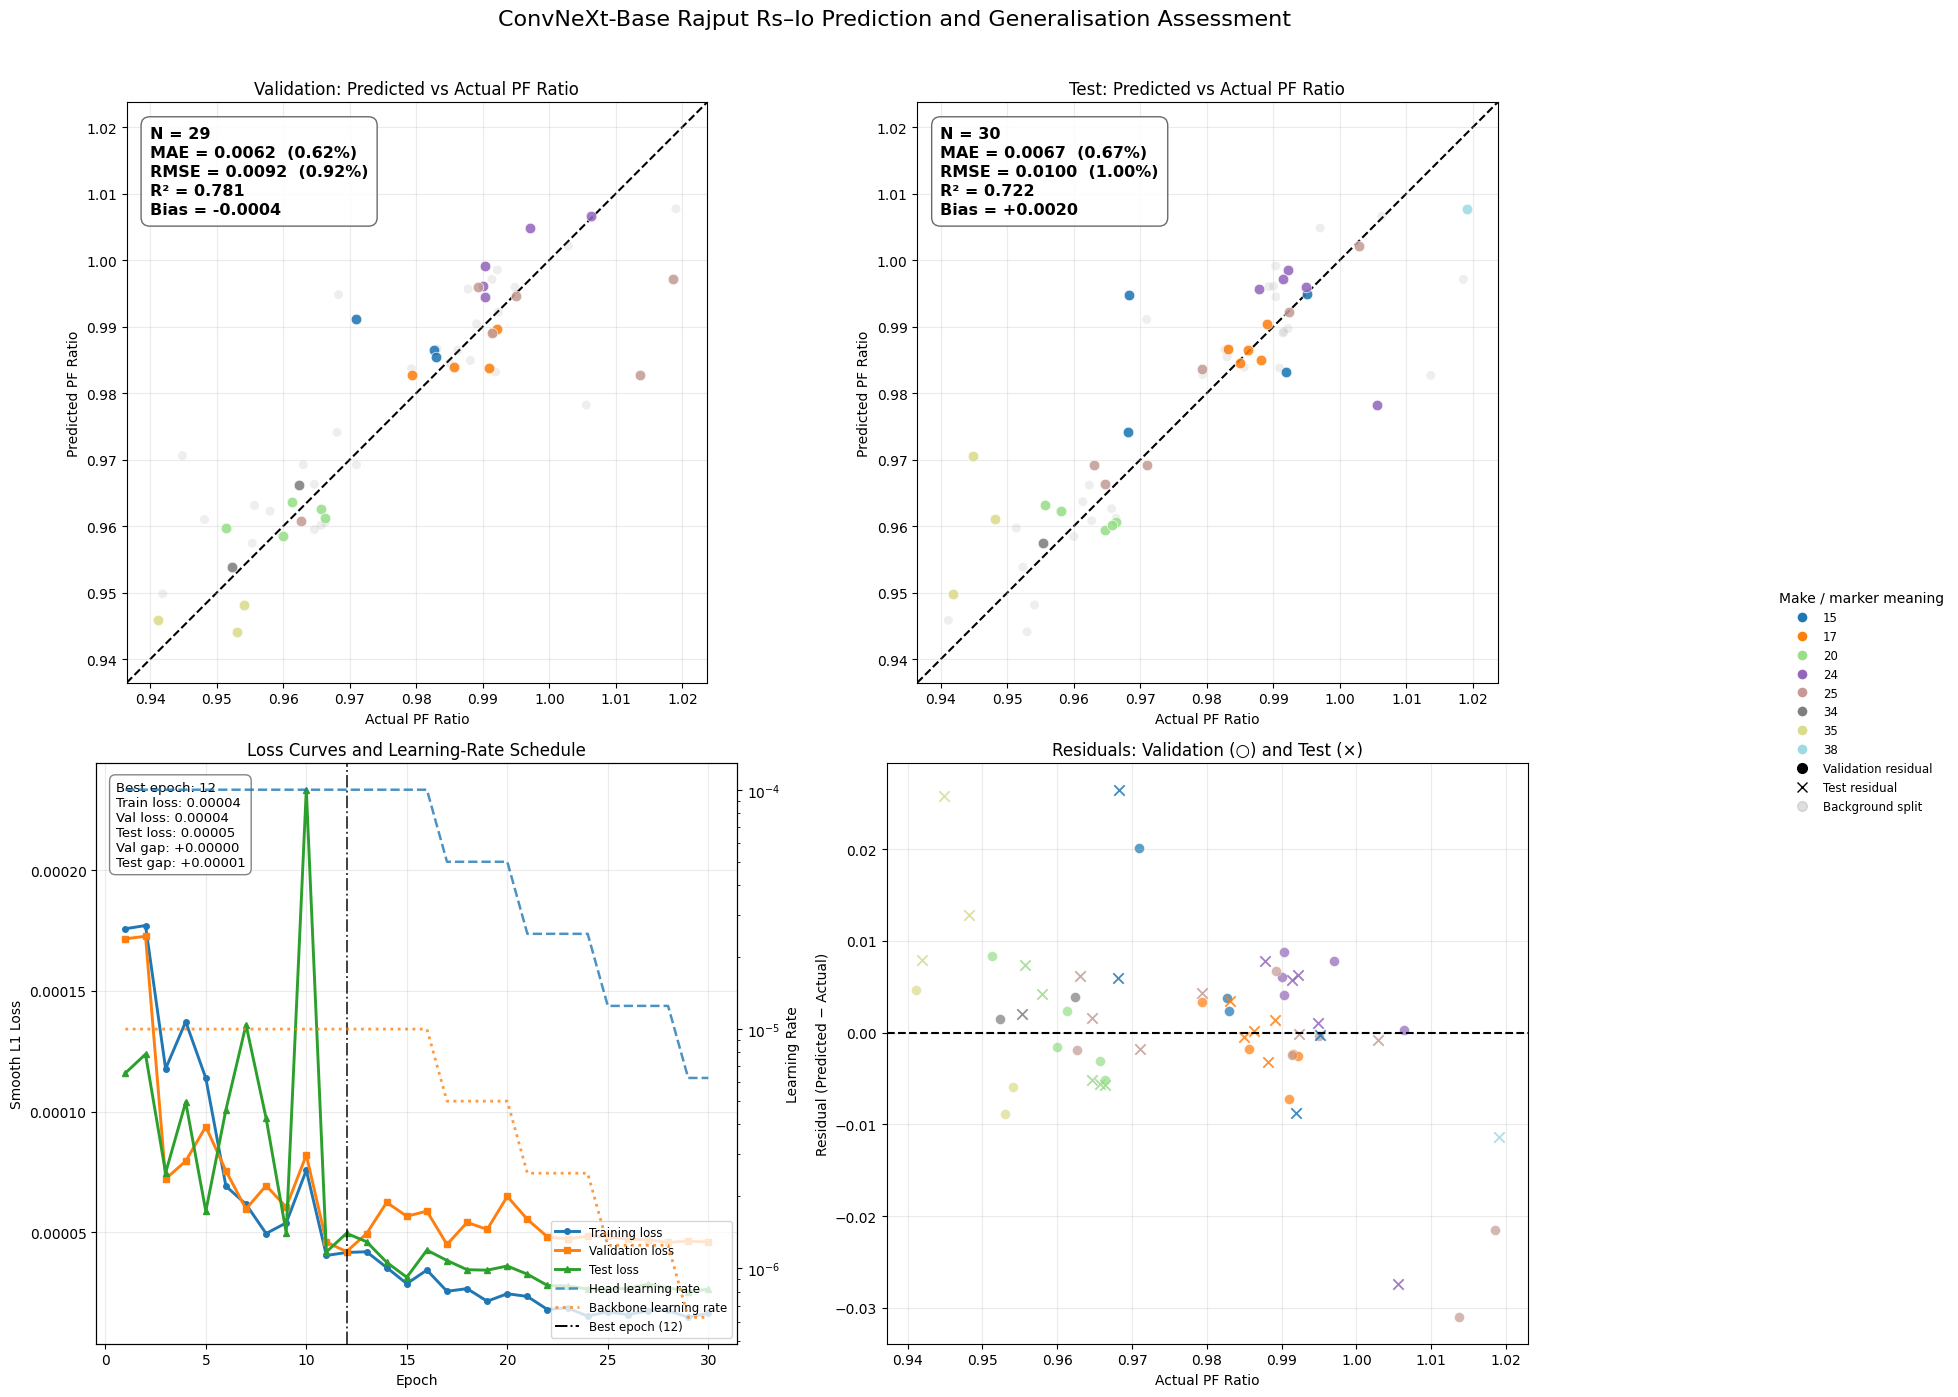


Saved:
- results_convnext_base_rajput_rs_io_fixedsplit_generalization.png
- validation_predictions_convnext_base_rajput_rs_io_fixedsplit.csv
- test_predictions_convnext_base_rajput_rs_io_fixedsplit.csv
- metrics_per_make_convnext_base_rajput_rs_io_fixedsplit.csv
- training_history_convnext_base_rajput_rs_io_fixedsplit.csv
- convnext_base_rajput_rs_io_fixedsplit_best_val_model.pth
Cleanup done.


In [4]:
import os
import math
import copy
import random
import time
import gc

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models


# =========================================================
# CONFIG
# =========================================================
CSV_PATH = "AnonDB_80_10_10_seed42.csv"
MAKE_COLUMN = "Make"
SPLIT_COLUMN = "split"
PHYSICS_MAP_DIR = "J0_Rs"  # folder containing Rs and Io/J0 TIFF maps

IMAGE_SIZE = 224
BATCH_SIZE = 2  # ConvNeXt-Base is heavy; use 1 if CUDA runs out of memory
NUM_EPOCHS = 30
LEARNING_RATE = 1e-4
BACKBONE_LR = 1e-5
RANDOM_SEED = 42
NUM_WORKERS = 0
PRELOAD_TO_RAM = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", DEVICE)
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA used by PyTorch:", torch.version.cuda)

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))


# =========================================================
# REPRODUCIBILITY
# =========================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    if torch.cuda.is_available():
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


set_seed(RANDOM_SEED)


# =========================================================
# HELPER FUNCTIONS
# =========================================================
def resolve_relative_path(path_str, base_dir, add_wrp=True):
    """Resolve paths from the CSV relative to the CSV directory."""
    if pd.isna(path_str):
        return None

    path_str = str(path_str).strip()
    if path_str == "":
        return None

    path_str = path_str.replace("\\", os.sep).replace("/", os.sep)

    if add_wrp:
        root, ext = os.path.splitext(path_str)
        if not root.endswith("_wrp"):
            path_str = root + "_wrp" + ext

    if os.path.isabs(path_str):
        return os.path.normpath(path_str)

    if path_str.startswith("." + os.sep):
        path_str = path_str[2:]

    return os.path.normpath(os.path.join(base_dir, path_str))


def derive_physics_paths(elh_path_str, base_dir):
    """
    Derive Rajput Rs and Io map paths from ELHPath.

    Example:
        ELHPath: ./EL/3883_35_1_01272020_80.tiff
        Rs:      ./J0_Rs/3883_35_1_01272020_Rs.tiff
        Io:      ./J0_Rs/3883_35_1_01272020_Io.tiff

    For compatibility, the Io map also falls back to _J0.tiff when _Io.tiff
    does not exist.
    """
    if pd.isna(elh_path_str):
        return None, None

    elh_path_str = str(elh_path_str).strip()
    if elh_path_str == "":
        return None, None

    filename = os.path.basename(elh_path_str)
    name, ext = os.path.splitext(filename)
    base_name = name.rsplit("_", 1)[0]

    rs_path = os.path.normpath(
        os.path.join(base_dir, PHYSICS_MAP_DIR, f"{base_name}_Rs{ext}")
    )

    io_path = os.path.normpath(
        os.path.join(base_dir, PHYSICS_MAP_DIR, f"{base_name}_Io{ext}")
    )
    j0_fallback = os.path.normpath(
        os.path.join(base_dir, PHYSICS_MAP_DIR, f"{base_name}_J0{ext}")
    )

    if not os.path.exists(io_path) and os.path.exists(j0_fallback):
        io_path = j0_fallback

    return rs_path, io_path


def prepare_dataframe(csv_path):
    """
    Load the fixed-split CSV, compute PF ratio, derive Rajput Rs/Io paths,
    and retain Make and split information for plotting.
    """
    base_dir = os.path.dirname(os.path.abspath(csv_path))
    df = pd.read_csv(csv_path)

    required_cols = [
        "ELHPath",
        "Pmp_(W)",
        "Nameplate_Pmp_(W)",
        MAKE_COLUMN,
        SPLIT_COLUMN,
    ]

    for col in required_cols:
        if col not in df.columns:
            raise ValueError(f"Missing required column in CSV: {col}")

    df["Pmp_(W)"] = pd.to_numeric(df["Pmp_(W)"], errors="coerce")
    df["Nameplate_Pmp_(W)"] = pd.to_numeric(
        df["Nameplate_Pmp_(W)"], errors="coerce"
    )

    df = df[
        df["Nameplate_Pmp_(W)"].notna()
        & (df["Nameplate_Pmp_(W)"] > 0)
        & df["Pmp_(W)"].notna()
    ].copy()

    df["pf_ratio"] = df["Pmp_(W)"] / df["Nameplate_Pmp_(W)"]

    paths = df["ELHPath"].apply(lambda p: derive_physics_paths(p, base_dir))
    df["rs_path"] = paths.apply(lambda item: item[0])
    df["io_path"] = paths.apply(lambda item: item[1])

    df = df[df["rs_path"].notna() & df["io_path"].notna()].copy()
    df["rs_exists"] = df["rs_path"].apply(os.path.exists)
    df["io_exists"] = df["io_path"].apply(os.path.exists)

    total_before = len(df)
    df = df[df["rs_exists"] & df["io_exists"]].copy()
    total_after = len(df)

    print(f"Rows with valid power data before map filtering: {total_before}")
    print(f"Rows with both Rs and Io/J0 maps existing: {total_after}")
    print(f"Rows removed due to missing physics map(s): {total_before - total_after}")

    df[SPLIT_COLUMN] = df[SPLIT_COLUMN].astype(str).str.strip().str.lower()
    valid_split_names = {"train", "val", "test"}
    unknown_splits = set(df[SPLIT_COLUMN].unique()) - valid_split_names
    if unknown_splits:
        raise ValueError(
            "Unknown values in split column: " + ", ".join(sorted(unknown_splits))
        )

    df["make_plot"] = df[MAKE_COLUMN].fillna("Unknown").astype(str)

    optional_id_cols = [
        c
        for c in ["ID", "ModuleID", "Module", "Serial", "PanelID"]
        if c in df.columns
    ]

    keep_cols = optional_id_cols + [
        MAKE_COLUMN,
        "make_plot",
        SPLIT_COLUMN,
        "rs_path",
        "io_path",
        "pf_ratio",
    ]
    return df[keep_cols].reset_index(drop=True)


# =========================================================
# IMAGE PROCESSING
# =========================================================
def read_physics_map(path):
    """Read a floating-point Rajput physics map without forcing it to uint8."""
    img = cv2.imread(path, cv2.IMREAD_UNCHANGED)
    if img is None:
        raise ValueError(f"Failed to load physics map: {path}")

    if img.ndim == 3:
        img = img[:, :, 0]

    img = img.astype(np.float32)
    return np.nan_to_num(img, nan=0.0, posinf=0.0, neginf=0.0)


def resize_with_padding_float(img, target_size=240):
    """Preserve map aspect ratio and pad to a float32 square input."""
    h, w = img.shape[:2]
    scale = target_size / max(h, w)
    new_w = max(1, int(round(w * scale)))
    new_h = max(1, int(round(h * scale)))

    interpolation = cv2.INTER_AREA if scale < 1 else cv2.INTER_LINEAR
    resized = cv2.resize(img, (new_w, new_h), interpolation=interpolation)

    canvas = np.zeros((target_size, target_size), dtype=np.float32)
    y0 = (target_size - new_h) // 2
    x0 = (target_size - new_w) // 2
    canvas[y0:y0 + new_h, x0:x0 + new_w] = resized
    return canvas


def robust_normalize_map(img, lower_percentile=1.0, upper_percentile=99.0):
    """
    Robust per-map normalization to [0, 1]. This preserves spatial patterns
    while reducing the influence of extreme Rs/Io pixels.
    """
    finite = img[np.isfinite(img)]
    if finite.size == 0:
        return np.zeros_like(img, dtype=np.float32)

    low = np.percentile(finite, lower_percentile)
    high = np.percentile(finite, upper_percentile)
    if high - low <= 1e-12:
        return np.zeros_like(img, dtype=np.float32)

    clipped = np.clip(img, low, high)
    return ((clipped - low) / (high - low)).astype(np.float32)


# =========================================================
# DATASET
# =========================================================
class RajputPhysicsDataset(Dataset):
    def __init__(self, dataframe, image_size=240, augment=False, preload=False):
        self.df = dataframe.reset_index(drop=True)
        self.image_size = image_size
        self.augment = augment
        self.cache = False

        if preload:
            self._preload_all()

    def _preload_all(self):
        n = len(self.df)
        expected_mb = n * 2 * self.image_size * self.image_size * 4 / (1024 ** 2)

        print(f"\nPreloading {n} samples ({n * 2} Rajput maps) into RAM...")
        print(f"Expected memory: ~{expected_mb:.0f} MB")

        t0 = time.time()
        self.cache_rs = np.empty(
            (n, self.image_size, self.image_size), dtype=np.float32
        )
        self.cache_io = np.empty(
            (n, self.image_size, self.image_size), dtype=np.float32
        )

        failed = 0
        for i in range(n):
            row = self.df.iloc[i]
            try:
                rs_img = read_physics_map(row["rs_path"])
                io_img = read_physics_map(row["io_path"])

                self.cache_rs[i] = resize_with_padding_float(
                    rs_img, self.image_size
                )
                self.cache_io[i] = resize_with_padding_float(
                    io_img, self.image_size
                )
            except Exception as e:
                print(f"Warning: failed to load sample {i}: {e}")
                self.cache_rs[i] = 0.0
                self.cache_io[i] = 0.0
                failed += 1

        elapsed = time.time() - t0
        mem_mb = (self.cache_rs.nbytes + self.cache_io.nbytes) / (1024 ** 2)
        print(
            f"Done in {elapsed:.1f}s | "
            f"RAM used: {mem_mb:.1f} MB | "
            f"Failed: {failed}"
        )
        self.cache = True

    def apply_same_augmentation(self, rs_img, io_img):
        if random.random() < 0.5:
            rs_img = cv2.flip(rs_img, 1)
            io_img = cv2.flip(io_img, 1)
        if random.random() < 0.5:
            rs_img = cv2.flip(rs_img, 0)
            io_img = cv2.flip(io_img, 0)
        return rs_img, io_img

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        if self.cache:
            rs_img = self.cache_rs[idx].copy()
            io_img = self.cache_io[idx].copy()
        else:
            rs_img = resize_with_padding_float(
                read_physics_map(row["rs_path"]), self.image_size
            )
            io_img = resize_with_padding_float(
                read_physics_map(row["io_path"]), self.image_size
            )

        if self.augment:
            rs_img, io_img = self.apply_same_augmentation(rs_img, io_img)

        rs_img = robust_normalize_map(rs_img)
        io_img = robust_normalize_map(io_img)

        rs_img = np.expand_dims(rs_img, axis=0)
        io_img = np.expand_dims(io_img, axis=0)

        # Channel 0 = Rajput Rs map; channel 1 = Rajput Io/J0 map
        x = np.concatenate([rs_img, io_img], axis=0)
        y = float(row["pf_ratio"])

        return (
            torch.tensor(x, dtype=torch.float32),
            torch.tensor(y, dtype=torch.float32),
        )


# =========================================================
# MODEL
# =========================================================
class BoundedOutput(nn.Module):
    def __init__(self, in_features, min_val=0.80, max_val=1.20):
        super().__init__()
        self.linear = nn.Linear(in_features, 1)
        self.min_val = min_val
        self.max_val = max_val

    def forward(self, x):
        x = torch.sigmoid(self.linear(x))
        return x * (self.max_val - self.min_val) + self.min_val


def build_convnext_base_rajput_2ch(pretrained=True):
    """ConvNeXt-Base modified for two Rajput physics-map channels: Rs and Io/J0."""
    weights = models.ConvNeXt_Base_Weights.DEFAULT if pretrained else None
    model = models.convnext_base(weights=weights)

    # ConvNeXt stem: features[0][0] = Conv2d(3, 128, kernel_size=4, stride=4)
    old_conv = model.features[0][0]

    new_conv = nn.Conv2d(
        in_channels=2,
        out_channels=old_conv.out_channels,
        kernel_size=old_conv.kernel_size,
        stride=old_conv.stride,
        padding=old_conv.padding,
        bias=(old_conv.bias is not None),
    )

    with torch.no_grad():
        if pretrained:
            # Use grayscale-like ImageNet filters for both physics-map channels.
            # Multiplying by 0.5 keeps activation magnitude stable after using 2 channels.
            rgb_mean = old_conv.weight.mean(dim=1)
            new_conv.weight[:, 0, :, :] = rgb_mean
            new_conv.weight[:, 1, :, :] = rgb_mean
            new_conv.weight *= 0.5

            if old_conv.bias is not None:
                new_conv.bias.copy_(old_conv.bias)
        else:
            nn.init.kaiming_normal_(
                new_conv.weight, mode="fan_out", nonlinearity="relu"
            )
            if new_conv.bias is not None:
                nn.init.zeros_(new_conv.bias)

    model.features[0][0] = new_conv

    # ConvNeXt classifier: Sequential(LayerNorm2d, Flatten, Linear(...))
    in_features = model.classifier[2].in_features
    model.classifier[2] = BoundedOutput(
        in_features, min_val=0.80, max_val=1.20
    )

    return model


# =========================================================
# TRAIN / EVALUATE
# =========================================================
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0

    for inputs, targets in loader:
        inputs = inputs.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True).unsqueeze(1)

        optimizer.zero_grad(set_to_none=True)

        outputs = model(inputs)
        loss = criterion(outputs, targets)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

    return running_loss / len(loader.dataset)


def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    preds = []
    trues = []

    with torch.no_grad():
        for inputs, targets in loader:
            inputs = inputs.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True).unsqueeze(1)

            outputs = model(inputs)
            loss = criterion(outputs, targets)

            running_loss += loss.item() * inputs.size(0)

            preds.extend(outputs.squeeze(1).cpu().numpy())
            trues.extend(targets.squeeze(1).cpu().numpy())

    preds = np.asarray(preds)
    trues = np.asarray(trues)

    loss_value = running_loss / len(loader.dataset)
    mae = mean_absolute_error(trues, preds)
    rmse = math.sqrt(mean_squared_error(trues, preds))
    r2 = r2_score(trues, preds) if len(trues) >= 2 else np.nan

    return loss_value, mae, rmse, r2, preds, trues


# =========================================================
# PLOTTING HELPERS
# =========================================================
def build_make_palette(make_values):
    """Create a stable qualitative colour palette for all Make values."""
    makes = sorted(pd.Series(make_values).fillna("Unknown").astype(str).unique())

    # tab20 is clear and publication-friendly for up to roughly 20 categories.
    base_cmap = plt.colormaps.get_cmap("tab20")
    colours = [base_cmap(i / max(1, len(makes) - 1)) for i in range(len(makes))]

    return dict(zip(makes, colours))


def common_scatter_limits(*dataframes):
    values = []

    for df in dataframes:
        values.extend(df["actual_pf_ratio"].to_numpy())
        values.extend(df["predicted_pf_ratio"].to_numpy())

    minimum = float(np.min(values))
    maximum = float(np.max(values))
    margin = max((maximum - minimum) * 0.06, 0.003)

    return minimum - margin, maximum + margin


def plot_focus_scatter_with_background(
    ax,
    focus_df,
    background_df,
    make_palette,
    title,
    background_label,
    axis_limits,
):
    """Highlight one split by Make and show the other split in faint grey."""
    ax.scatter(
        background_df["actual_pf_ratio"],
        background_df["predicted_pf_ratio"],
        s=42,
        color="grey",
        alpha=0.13,
        edgecolors="none",
        label=background_label,
        zorder=1,
    )

    for make_value, group in focus_df.groupby("make_plot", sort=True):
        ax.scatter(
            group["actual_pf_ratio"],
            group["predicted_pf_ratio"],
            s=58,
            color=make_palette[make_value],
            alpha=0.88,
            edgecolors="white",
            linewidths=0.5,
            label=make_value,
            zorder=2,
        )

    minimum, maximum = axis_limits

    ax.plot(
        [minimum, maximum],
        [minimum, maximum],
        linestyle="--",
        linewidth=1.5,
        color="black",
        label="Ideal prediction",
        zorder=0,
    )

    ax.set_xlim(minimum, maximum)
    ax.set_ylim(minimum, maximum)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("Actual PF Ratio")
    ax.set_ylabel("Predicted PF Ratio")
    ax.set_title(title)
    ax.grid(True, alpha=0.25)

    # Large, direct performance annotation for the highlighted split.
    actual = focus_df["actual_pf_ratio"].to_numpy()
    predicted = focus_df["predicted_pf_ratio"].to_numpy()
    residual = predicted - actual

    mae = mean_absolute_error(actual, predicted)
    rmse = math.sqrt(mean_squared_error(actual, predicted))
    r2 = r2_score(actual, predicted) if len(actual) >= 2 else float("nan")
    bias = float(np.mean(residual))

    metrics_text = (
        f"N = {len(actual)}\n"
        f"MAE = {mae:.4f}  ({mae * 100:.2f}%)\n"
        f"RMSE = {rmse:.4f}  ({rmse * 100:.2f}%)\n"
        f"R² = {r2:.3f}\n"
        f"Bias = {bias:+.4f}"
    )

    ax.text(
        0.04,
        0.96,
        metrics_text,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=11.5,
        fontweight="bold",
        linespacing=1.35,
        bbox=dict(
            boxstyle="round,pad=0.55",
            facecolor="white",
            edgecolor="0.35",
            alpha=0.90,
        ),
        zorder=5,
    )


def plot_loss_and_scheduler(
    ax,
    train_losses,
    val_losses,
    test_losses,
    head_lrs,
    backbone_lrs,
    best_epoch,
):
    """
    Left axis: training, validation, and test loss.
    Right axis: head and backbone learning rates.
    """
    epochs = np.arange(1, len(train_losses) + 1)

    loss_lines = []
    loss_lines += ax.plot(
        epochs,
        train_losses,
        marker="o",
        markersize=4,
        linewidth=2.1,
        label="Training loss",
    )
    loss_lines += ax.plot(
        epochs,
        val_losses,
        marker="s",
        markersize=4,
        linewidth=2.1,
        label="Validation loss",
    )
    loss_lines += ax.plot(
        epochs,
        test_losses,
        marker="^",
        markersize=4,
        linewidth=2.1,
        label="Test loss",
    )

    ax.axvline(
        best_epoch,
        linestyle="-.",
        linewidth=1.4,
        color="black",
        alpha=0.75,
        label=f"Best epoch ({best_epoch})",
    )

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Smooth L1 Loss")
    ax.set_title("Loss Curves and Learning-Rate Schedule")
    ax.grid(True, alpha=0.25)

    ax_lr = ax.twinx()

    lr_lines = []
    lr_lines += ax_lr.plot(
        epochs,
        head_lrs,
        linestyle="--",
        linewidth=1.8,
        alpha=0.8,
        label="Head learning rate",
    )
    lr_lines += ax_lr.plot(
        epochs,
        backbone_lrs,
        linestyle=":",
        linewidth=2.0,
        alpha=0.8,
        label="Backbone learning rate",
    )

    ax_lr.set_ylabel("Learning Rate")
    ax_lr.set_yscale("log")

    best_idx = best_epoch - 1
    val_gap = val_losses[best_idx] - train_losses[best_idx]
    test_gap = test_losses[best_idx] - train_losses[best_idx]

    generalisation_text = (
        f"Best epoch: {best_epoch}\n"
        f"Train loss: {train_losses[best_idx]:.5f}\n"
        f"Val loss: {val_losses[best_idx]:.5f}\n"
        f"Test loss: {test_losses[best_idx]:.5f}\n"
        f"Val gap: {val_gap:+.5f}\n"
        f"Test gap: {test_gap:+.5f}"
    )

    ax.text(
        0.03,
        0.97,
        generalisation_text,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=9.5,
        bbox=dict(
            boxstyle="round,pad=0.45",
            facecolor="white",
            edgecolor="0.45",
            alpha=0.88,
        ),
        zorder=5,
    )

    # Include the best-epoch line in the combined legend.
    best_epoch_handle = Line2D(
        [0], [0], linestyle="-.", color="black", linewidth=1.4,
        label=f"Best epoch ({best_epoch})"
    )

    all_lines = loss_lines + lr_lines + [best_epoch_handle]
    all_labels = [line.get_label() for line in all_lines]

    ax.legend(
        all_lines,
        all_labels,
        loc="lower right",
        fontsize=8.5,
        frameon=True,
    )


def plot_residuals_by_split(ax, val_results_df, test_results_df, make_palette):
    """
    Residual plot helps reveal systematic bias, heteroscedasticity,
    and differences between validation and test behaviour.
    """
    for make_value, group in val_results_df.groupby("make_plot", sort=True):
        ax.scatter(
            group["actual_pf_ratio"],
            group["residual"],
            color=make_palette[make_value],
            marker="o",
            s=52,
            alpha=0.72,
            edgecolors="white",
            linewidths=0.4,
        )

    for make_value, group in test_results_df.groupby("make_plot", sort=True):
        ax.scatter(
            group["actual_pf_ratio"],
            group["residual"],
            color=make_palette[make_value],
            marker="x",
            s=56,
            alpha=0.85,
            linewidths=1.3,
        )

    ax.axhline(0.0, linestyle="--", linewidth=1.5, color="black")
    ax.set_xlabel("Actual PF Ratio")
    ax.set_ylabel("Residual (Predicted − Actual)")
    ax.set_title("Residuals: Validation (○) and Test (×)")
    ax.grid(True, alpha=0.25)


def make_prediction_table(base_df, trues, preds, split_name):
    results = base_df.reset_index(drop=True).copy()
    results["actual_pf_ratio"] = trues
    results["predicted_pf_ratio"] = preds
    results["residual"] = preds - trues
    results["absolute_error"] = np.abs(preds - trues)
    results["evaluation_split"] = split_name
    return results


def calculate_metrics_per_make(results_df, split_name):
    rows = []

    for make_value, group in results_df.groupby("make_plot", sort=True):
        actual = group["actual_pf_ratio"].to_numpy()
        predicted = group["predicted_pf_ratio"].to_numpy()

        rows.append(
            {
                "Make": make_value,
                "Split": split_name,
                "N": len(group),
                "MAE": mean_absolute_error(actual, predicted),
                "RMSE": math.sqrt(mean_squared_error(actual, predicted)),
                "R2": r2_score(actual, predicted) if len(group) >= 2 else np.nan,
                "Mean_residual": float(np.mean(predicted - actual)),
            }
        )

    return pd.DataFrame(rows)


# =========================================================
# MAIN
# =========================================================
def main():
    df = prepare_dataframe(CSV_PATH)

    # Rajput maps may only exist for a subset of modules, e.g. 60-cell modules.
    # Therefore, do not require a minimum total sample count or complete Make coverage.
    # Only the global train/val/test splits must be non-empty after map filtering.
    if len(df) < 20:
        print(
            f"\nWarning: only {len(df)} valid Rajput samples remain after filtering. "
            "Continuing because this is expected when only some modules have Rajput maps."
        )

    print("\nSample rows:")
    print(df.head())

    print("\nSplit counts after file filtering:")
    print(df[SPLIT_COLUMN].value_counts().reindex(["train", "val", "test"]))

    print("\nMake by split after Rajput map filtering:")
    make_split_table = pd.crosstab(df["make_plot"], df[SPLIT_COLUMN])
    print(make_split_table)
    print(
        "\nNote: missing Make categories are allowed here because Rajput Rs/Io maps "
        "may only be available for selected modules, such as 60-cell modules."
    )

    train_df = df[df[SPLIT_COLUMN] == "train"].copy().reset_index(drop=True)
    val_df = df[df[SPLIT_COLUMN] == "val"].copy().reset_index(drop=True)
    test_df = df[df[SPLIT_COLUMN] == "test"].copy().reset_index(drop=True)

    if min(len(train_df), len(val_df), len(test_df)) == 0:
        raise ValueError("Train, validation, or test split is empty after filtering.")

    print(f"\nTrain samples: {len(train_df)}")
    print(f"Val samples:   {len(val_df)}")
    print(f"Test samples:  {len(test_df)}")

    train_dataset = RajputPhysicsDataset(
        train_df, image_size=IMAGE_SIZE, augment=True, preload=PRELOAD_TO_RAM
    )
    val_dataset = RajputPhysicsDataset(
        val_df, image_size=IMAGE_SIZE, augment=False, preload=PRELOAD_TO_RAM
    )
    test_dataset = RajputPhysicsDataset(
        test_df, image_size=IMAGE_SIZE, augment=False, preload=PRELOAD_TO_RAM
    )

    pin_memory = DEVICE.type == "cuda"

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=pin_memory,
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=pin_memory,
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=pin_memory,
    )

    model = build_convnext_base_rajput_2ch(pretrained=True).to(DEVICE)

    print("Model is on:", next(model.parameters()).device)

    backbone_params = list(model.features.parameters())
    head_params = list(model.classifier.parameters())

    print(f"\nBackbone parameters: {sum(p.numel() for p in backbone_params):,}")
    print(f"Head parameters:     {sum(p.numel() for p in head_params):,}")
    print(f"Total parameters:    {sum(p.numel() for p in model.parameters()):,}")
    print(f"Backbone LR: {BACKBONE_LR:.1e} | Head LR: {LEARNING_RATE:.1e}")

    criterion = nn.SmoothL1Loss()

    optimizer = torch.optim.AdamW(
        [
            {"params": backbone_params, "lr": BACKBONE_LR},
            {"params": head_params, "lr": LEARNING_RATE},
        ],
        weight_decay=1e-2,
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=3
    )

    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_rmse = float("inf")
    best_epoch = 1

    train_losses = []
    val_losses = []
    test_losses = []
    head_lrs = []
    backbone_lrs = []

    print(f"\n{'=' * 78}")
    print("Starting training: ConvNeXt-Base, Rajput Rs+Io maps, fixed split CSV")
    print(f"Image size: {IMAGE_SIZE}x{IMAGE_SIZE} | Batch size: {BATCH_SIZE}")
    print(f"{'=' * 78}\n")

    total_t0 = time.time()

    for epoch in range(NUM_EPOCHS):
        epoch_t0 = time.time()

        current_backbone_lr = optimizer.param_groups[0]["lr"]
        current_head_lr = optimizer.param_groups[1]["lr"]

        backbone_lrs.append(current_backbone_lr)
        head_lrs.append(current_head_lr)

        train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)

        train_eval_loss, train_mae, train_rmse, train_r2, _, _ = evaluate(
            model, train_loader, criterion, DEVICE
        )
        val_loss, val_mae, val_rmse, val_r2, _, _ = evaluate(
            model, val_loader, criterion, DEVICE
        )
        test_loss, test_mae, test_rmse, test_r2, _, _ = evaluate(
            model, test_loader, criterion, DEVICE
        )

        scheduler.step(val_loss)

        train_losses.append(train_eval_loss)
        val_losses.append(val_loss)
        test_losses.append(test_loss)

        epoch_time = time.time() - epoch_t0

        print(
            f"Epoch [{epoch + 1:02d}/{NUM_EPOCHS}] | "
            f"{epoch_time:.1f}s | "
            f"BB_LR: {current_backbone_lr:.2e} | "
            f"Head_LR: {current_head_lr:.2e} | "
            f"Train Loss: {train_eval_loss:.6f} | "
            f"Val Loss: {val_loss:.6f} | "
            f"Test Loss: {test_loss:.6f} | "
            f"Val MAE: {val_mae:.6f} | "
            f"Val RMSE: {val_rmse:.6f} | "
            f"Val R2: {val_r2:.6f}"
        )

        if val_rmse < best_val_rmse:
            best_val_rmse = val_rmse
            best_epoch = epoch + 1
            best_model_wts = copy.deepcopy(model.state_dict())

    total_time = time.time() - total_t0
    print(f"\nTraining complete in {total_time:.1f}s ({total_time / 60:.1f} min)")

    # =====================================================
    # FINAL EVALUATION USING THE BEST VALIDATION MODEL
    # =====================================================
    model.load_state_dict(best_model_wts)

    val_loss, val_mae, val_rmse, val_r2, val_preds, val_trues = evaluate(
        model, val_loader, criterion, DEVICE
    )
    test_loss, test_mae, test_rmse, test_r2, test_preds, test_trues = evaluate(
        model, test_loader, criterion, DEVICE
    )

    print(f"\nBest epoch selected by validation RMSE: {best_epoch}")

    print("\nValidation Set")
    print(f"MAE  : {val_mae:.6f}")
    print(f"RMSE : {val_rmse:.6f}")
    print(f"R2   : {val_r2:.6f}")

    print("\nTest Set")
    print(f"MAE  : {test_mae:.6f}")
    print(f"RMSE : {test_rmse:.6f}")
    print(f"R2   : {test_r2:.6f}")

    best_idx = best_epoch - 1
    print("\nGeneralisation gaps at the best epoch")
    print(
        "Validation loss − training loss: "
        f"{val_losses[best_idx] - train_losses[best_idx]:.6f}"
    )
    print(
        "Test loss − training loss:       "
        f"{test_losses[best_idx] - train_losses[best_idx]:.6f}"
    )

    val_results_df = make_prediction_table(
        val_df, val_trues, val_preds, "validation"
    )
    test_results_df = make_prediction_table(
        test_df, test_trues, test_preds, "test"
    )

    make_palette = build_make_palette(df["make_plot"])
    axis_limits = common_scatter_limits(val_results_df, test_results_df)

    # =====================================================
    # FOUR-PANEL FIGURE
    # =====================================================
    fig, axes = plt.subplots(2, 2, figsize=(18, 14))

    plot_focus_scatter_with_background(
        axes[0, 0],
        focus_df=val_results_df,
        background_df=test_results_df,
        make_palette=make_palette,
        title="Validation: Predicted vs Actual PF Ratio",
        background_label="Test background",
        axis_limits=axis_limits,
    )

    plot_focus_scatter_with_background(
        axes[0, 1],
        focus_df=test_results_df,
        background_df=val_results_df,
        make_palette=make_palette,
        title="Test: Predicted vs Actual PF Ratio",
        background_label="Validation background",
        axis_limits=axis_limits,
    )

    plot_loss_and_scheduler(
        axes[1, 0],
        train_losses=train_losses,
        val_losses=val_losses,
        test_losses=test_losses,
        head_lrs=head_lrs,
        backbone_lrs=backbone_lrs,
        best_epoch=best_epoch,
    )

    plot_residuals_by_split(
        axes[1, 1], val_results_df, test_results_df, make_palette
    )

    # One shared legend for Make categories.
    make_handles = [
        Line2D(
            [0], [0],
            marker="o",
            color="none",
            markerfacecolor=make_palette[make_value],
            markeredgecolor="white",
            markersize=8,
            label=make_value,
        )
        for make_value in sorted(make_palette)
    ]

    split_handles = [
        Line2D(
            [0], [0], marker="o", linestyle="None", color="black",
            markersize=7, label="Validation residual"
        ),
        Line2D(
            [0], [0], marker="x", linestyle="None", color="black",
            markersize=7, label="Test residual"
        ),
        Line2D(
            [0], [0], marker="o", linestyle="None", color="grey",
            alpha=0.25, markersize=7, label="Background split"
        ),
    ]

    fig.legend(
        handles=make_handles + split_handles,
        loc="center left",
        bbox_to_anchor=(0.985, 0.5),
        frameon=False,
        title="Make / marker meaning",
        fontsize=8.5,
    )

    fig.suptitle(
        "ConvNeXt-Base Rajput Rs–Io Prediction and Generalisation Assessment",
        fontsize=16,
        y=0.995,
    )

    plt.tight_layout(rect=[0, 0, 0.86, 0.98])

    result_fig_path = "results_convnext_base_rajput_rs_io_fixedsplit_generalization.png"
    plt.savefig(result_fig_path, dpi=300, bbox_inches="tight")
    plt.show()

    # =====================================================
    # SAVE OUTPUTS
    # =====================================================
    val_csv_path = "validation_predictions_convnext_base_rajput_rs_io_fixedsplit.csv"
    test_csv_path = "test_predictions_convnext_base_rajput_rs_io_fixedsplit.csv"
    metrics_csv_path = "metrics_per_make_convnext_base_rajput_rs_io_fixedsplit.csv"
    history_csv_path = "training_history_convnext_base_rajput_rs_io_fixedsplit.csv"
    model_path = "convnext_base_rajput_rs_io_fixedsplit_best_val_model.pth"

    val_results_df.to_csv(val_csv_path, index=False)
    test_results_df.to_csv(test_csv_path, index=False)

    val_make_metrics = calculate_metrics_per_make(
        val_results_df, "validation"
    )
    test_make_metrics = calculate_metrics_per_make(
        test_results_df, "test"
    )
    make_metrics = pd.concat(
        [val_make_metrics, test_make_metrics], ignore_index=True
    )
    make_metrics.to_csv(metrics_csv_path, index=False)

    history_df = pd.DataFrame(
        {
            "epoch": np.arange(1, NUM_EPOCHS + 1),
            "train_loss": train_losses,
            "validation_loss": val_losses,
            "test_loss": test_losses,
            "backbone_lr": backbone_lrs,
            "head_lr": head_lrs,
            "is_best_epoch": [
                epoch == best_epoch for epoch in range(1, NUM_EPOCHS + 1)
            ],
        }
    )
    history_df.to_csv(history_csv_path, index=False)

    torch.save(model.state_dict(), model_path)

    print("\nSaved:")
    print(f"- {result_fig_path}")
    print(f"- {val_csv_path}")
    print(f"- {test_csv_path}")
    print(f"- {metrics_csv_path}")
    print(f"- {history_csv_path}")
    print(f"- {model_path}")


if __name__ == "__main__":
    try:
        main()
    except KeyboardInterrupt:
        print("\nTraining stopped manually by user.")
    finally:
        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            torch.cuda.ipc_collect()

        print("Cleanup done.")
